In [1]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam, vcf, subprocess
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO
import scipy.stats as st

df_isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
df_ASM_QC = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/hybridASM_QC.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_max = 0.03
h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                  }

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

Lineage
2      381
4      330
3       48
2,4      6
1        1
2,3      1
Name: count, dtype: int64
rrs
rrl
rrf


In [89]:
df_run['SampleID'] = [os.path.basename(fName).split('.fastq.gz')[0].replace('TWGSCUL', '').replace('TWGSCul_', '').replace('TB_', '').replace('TOTAL_', '').replace('TWGCul_', '').replace('TCul_', '').replace('TCUL', '').split('_')[0] for fName in df_run.FQ1.values]
print(len(df_run))

df_run.loc[(df_run["SampleID"].str.contains('CT')) & (df_run["SampleID"]).str.endswith('01'), 'SampleID'] = df_run.loc[(df_run["SampleID"].str.contains('CT')) & (df_run["SampleID"]).str.endswith('01')]['SampleID'].str[:-2]
print(len(df_run))

df_run = df_run.query("~(SampleID == 'CT0023' & ~FQ1.str.contains('combined'))").reset_index(drop=True)
print(len(df_run))

df_run['FQ2'] = df_run['FQ1'].str.replace('R1', 'R2')

df_run.SampleID.nunique(), len(df_run)

80
80
78


(78, 78)

In [75]:
df_run.iloc[df_run.index.values[df_run.duplicated(subset='SampleID', keep=False)]].sort_values('SampleID').FQ1.values

array([], dtype=object)

In [10]:
df_WGS.query("pid in @df_run.SampleID").shape

(63, 14)

In [11]:
set(df_WGS.pid) - set(df_run.SampleID)

{'CT000101', 'CT000301'}

In [12]:
len(set(df_run.SampleID) - set(df_WGS.pid))

15

In [13]:
df_run.query("SampleID=='CT0014'")

,FQ1,SampleID,FQ2,pid,FQ
30,/n/data1/hms/dbmi/farhat/fastq_db/TOTAL/FASTQs...,CT0014,/n/data1/hms/dbmi/farhat/fastq_db/TOTAL/FASTQs...,CT0014,0


In [14]:
for i, row in df_run.iterrows():#.query("SampleID not in @df_WGS.pid").iterrows():
    
    assert os.path.isfile(row['FQ1'])
    assert os.path.isfile(row['FQ2'])
    assert row['FQ1'] != row['FQ2']

In [15]:
# for i, row in df_run.query("SampleID not in @df_WGS.pid").iterrows():
    
#     sample = row['SampleID']
#     out_dir = f"/n/scratch/users/s/sak0914/TOTAL_FQ/{sample}"
    
#     os.makedirs(out_dir, exist_ok=True)
    
#     shutil.copy(row['FQ1'], f"{out_dir}/{sample}_R1.fastq.gz")
#     shutil.copy(row['FQ2'], f"{out_dir}/{sample}_R2.fastq.gz")

In [16]:
df_run['pid'] = df_run['SampleID']
df_run['FQ'] = 0

In [24]:
df_run[['pid', 'SampleID', 'FQ']].query("SampleID not in @df_WGS.pid").to_csv("~/Mtb_Megapipe/TOTAL_isolates_to_run.tsv", sep='\t', header=None, index=False)

In [237]:
for i, row in df_run.iterrows():
    sample = row['SampleID']
    if os.path.isfile(f"/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_processed/{sample}/pilon/{sample}_variants.vcf"):
        df_run.loc[i, 'Finished'] = 1

In [19]:
df_depth = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_processed/CT0014/bam/CT0014.depth.tsv.gz", compression='gzip', header=None, sep='\t')

In [21]:
df_depth[2].median()

39.0

In [22]:
len(df_depth.loc[df_depth[2] >= 20]) / len(df_depth)

0.9637389006812146

In [239]:
df_depth = pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_processed/CT0021/bam/CT0021.depth.tsv.gz",
                       sep='\t',
                       header=None,
                       compression='gzip'
                      )

In [241]:
df_depth[2].median()

32.0

In [243]:
len(df_depth.loc[df_depth[2] >= 20])/len(df_depth)

0.942400961842734

In [9]:
df_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_summary.csv")
len(df_WGS)

65

In [2]:
def extract_kraken_reports(df, sample_id_col, run_id_col, out_dir=None):

    df_add = pd.DataFrame(columns = [sample_id_col, run_id_col, 'Kraken_Unclassified_Percent'])
    k = 0

    if out_dir is None:
        out_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"
    
    for i, name in enumerate(df[sample_id_col].values):

        for run_id in np.sort(df.query(f"{sample_id_col}==@name")[run_id_col].values[0].split(',')):
    
            if os.path.isfile(f"{out_dir}/{name}/{run_id}/kraken/kraken_report"):
        
                df_kraken = pd.read_csv(f"{out_dir}/{name}/{run_id}/kraken/kraken_report", sep='\t', header=None)

                kraken_unclassified = df_kraken.loc[df_kraken[3]=='U'][0].values[0]

                df_add.loc[k, :] = [name, run_id, kraken_unclassified]
                k += 1
    
    return df_add
    
    
    
    
def compute_BAM_depth_metrics(df, sample_id_col, run_id_col, out_dir=None):

    df_BAM_depths = pd.DataFrame(columns = [sample_id_col, run_id_col, 'Mean_Depth', 'Median_Depth', 'Prop_20x', 'Prop_10x'])
    idx = 0

    if out_dir is None:
        out_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"
    
    for i, name in enumerate(df[sample_id_col].values):

        run_ids = np.sort(df.query(f"{sample_id_col}==@name")[run_id_col].values[0].split(','))
    
        if os.path.isfile(f"{out_dir}/{name}/bam/{name}.depth.tsv.gz"):
    
            df_depth = pd.read_csv(f"{out_dir}/{name}/bam/{name}.depth.tsv.gz", compression='gzip', header=None, sep='\t')
        
            pass_props = []
            
            for k, col in enumerate(df_depth.columns[2:]):

                mean_depth = df_depth[col].mean()
                median_depth = df_depth[col].median()
                prop_20x = len(df_depth.loc[df_depth[col] >= 20]) / len(df_depth)
                prop_10x = len(df_depth.loc[df_depth[col] >= 10]) / len(df_depth)

                df_BAM_depths.loc[idx, :] = [name, run_ids[k], mean_depth, median_depth, prop_20x, prop_10x]
                idx += 1
    
        else:
            print(f"No depth file for {name}")
    
        if i % 1000 == 0:
            print(i)
    
    return df_BAM_depths


def extract_lineages(df, name_col, out_dir=None):

    df_add = []

    if out_dir is None:
        out_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"
    
    for sample in df[name_col].unique():

        try:
            flc_fName = f"{out_dir}/{sample}/lineage/fast_lineage_caller_output.txt"
            
            if os.path.isfile(flc_fName):

                F2 = float(pd.read_csv(f"{out_dir}/{sample}/lineage/F2_Coll2014.txt", sep='\t', header=None)[0].values[0])

                df_flc = pd.read_csv(f"{out_dir}/{sample}/lineage/fast_lineage_caller_output.txt", sep='\t')

                df_flc['ROLLINGDB_ID'] = os.path.basename(os.path.dirname(os.path.dirname(flc_fName)))

                for col in df_flc.columns:
                    if col not in ['Isolate', 'ROLLINGDB_ID']:
                        df_flc.rename(columns={col: col.capitalize()}, inplace=True)

                df_flc['Coll2014'] = df_flc['Coll2014'].str.replace('lineage', '')
                df_flc['F2'] = F2

                split_lineages = df_flc['Coll2014'].values[0].split(',')                

                unique_lineages = []

                for lineage in split_lineages:
                    if lineage[0].isnumeric():
                        unique_lineages.append(lineage[0])
                    else:
                        unique_lineages.append(lineage)

                df_flc['Lineage'] = ','.join(np.sort(np.unique(unique_lineages)))

                df_add.append(df_flc)
        except:
            print(f"{sample} failed")
    
    df_add = pd.concat(df_add).reset_index(drop=True)
    del df_add['Isolate']
    
    return df_add

In [36]:
df_kraken = extract_kraken_reports(df_run.query("SampleID not in @df_WGS.pid"), 'pid', 'SampleID', out_dir="/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_processed")

df_BAM_metrics = compute_BAM_depth_metrics(df_run.query("SampleID not in @df_WGS.pid"), 'pid', 'SampleID', out_dir="/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_processed")

df_lineages = extract_lineages(df_run.query("SampleID not in @df_WGS.pid"), 'pid', out_dir="/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_processed")



0


In [55]:
df_BAM_metrics['Perc_Sites_20x'] = df_BAM_metrics['Prop_20x'] * 100
df_BAM_metrics['Perc_Sites_10x'] = df_BAM_metrics['Prop_10x'] * 100

In [60]:
df_add = df_kraken.merge(df_lineages.rename(columns={'ROLLINGDB_ID': 'SampleID'}), on='SampleID').merge(df_BAM_metrics, on=['pid', 'SampleID'])

del df_add['Prop_20x']
del df_add['Prop_10x']

In [61]:
df_new = pd.concat([df_WGS.query("SampleID not in ['CT000101', 'CT000301']"), df_add])

In [64]:
df_new.query("Kraken_Unclassified_Percent > 20")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_20x,Perc_Sites_10x,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
2,CT0014,CT0014,66.74,43.864823,39.0,96.37389,97.905036,"4.4.1.1,4.3,4.2,4.4.1.2,4.6.1","4.2.1.2.2.1.1,1.1.1.2.i1","caprae,canetti,stype,mungi,westafrican1,dassie...",NaN,4,0.097017,4


In [67]:
df_new.query("F2 <= 0.03 & Perc_Sites_20x < 95")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_20x,Perc_Sites_10x,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
25,P0754,P0754,0.53,24.026782,24.0,78.128369,97.237876,2.2.1,2.2.1.1.1.i2,beijing,lin2.2.1,NaN,0.027656,2
27,P078801,P078801,0.47,24.083281,24.0,76.2468,96.996327,4.1.1.1,4.1.i1.2.1,xtype,NaN,4,0.014825,4
4,CT0021,CT0021,0.49,31.671449,32.0,94.240096,97.563386,2.2.1.1,2.2.1.1.1,beijing,"lin2.2.1,pacific_RD150",NaN,0.011711,2
5,CT0025,CT0025,0.52,28.88709,29.0,91.913195,97.433885,2.2.1.1,2.2.1.1.1,beijing,"lin2.2.1,pacific_RD150",NaN,0.013986,2
8,CT0030,CT0030,0.62,31.38398,32.0,94.508982,97.897986,4.3.2.1,4.2.1.2.1.1.i1,"lam,stype",NaN,4.3/LAM,0.010550,4
9,CT0031,CT0031,0.63,29.842743,30.0,92.897977,97.504926,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.014615,2
11,CT0033,CT0033,0.44,28.601605,29.0,90.224008,97.439937,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.018148,4


In [68]:
df_new.query("Kraken_Unclassified_Percent > 20")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_20x,Perc_Sites_10x,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
2,CT0014,CT0014,66.74,43.864823,39.0,96.37389,97.905036,"4.4.1.1,4.3,4.2,4.4.1.2,4.6.1","4.2.1.2.2.1.1,1.1.1.2.i1","caprae,canetti,stype,mungi,westafrican1,dassie...",NaN,4,0.097017,4


In [93]:
df_WGS.query("pid in ['CT0008', 'CT0014', 'CT0020', 'CT0021', 'CT0023', 'CT0024', 'CT0025', 'CT0026', 'CT0028', 'CT0030', 'CT0031', 'CT0032', 'CT0033', 'CT0035']")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_20x,Perc_Sites_10x,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
1,CT0008,CT0008,2.83,410.491285,420.0,98.194278,98.31741,2.2.1.1,2.2.1.1.1,beijing,"lin2.2.1,pacific_RD150",NaN,0.011483,2


In [94]:
# df_new.to_csv("/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/Illumina_culture_WGS_summary.csv", index=False)

In [96]:
df_new.query("Kraken_Unclassified_Percent > 20")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_20x,Perc_Sites_10x,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
2,CT0014,CT0014,66.74,43.864823,39.0,96.37389,97.905036,"4.4.1.1,4.3,4.2,4.4.1.2,4.6.1","4.2.1.2.2.1.1,1.1.1.2.i1","caprae,canetti,stype,mungi,westafrican1,dassie...",NaN,4,0.097017,4


In [103]:
df_new.query("F2 <= 0.03 & Kraken_Unclassified_Percent <= 20")

,pid,SampleID,Kraken_Unclassified_Percent,Mean_Depth,Median_Depth,Perc_Sites_20x,Perc_Sites_10x,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage
0,CT0005,CT0005,2.34,365.426999,373.0,98.257159,98.386071,2.2.1,2.2.1.1.1,beijing,lin2.2.1,NaN,0.012778,2
1,CT0008,CT0008,2.83,410.491285,420.0,98.194278,98.31741,2.2.1.1,2.2.1.1.1,beijing,"lin2.2.1,pacific_RD150",NaN,0.011483,2
2,CT0011,CT0011,1.94,260.39598,266.0,98.123554,98.267291,2.2.1.1,2.2.1.1.1,beijing,"lin2.2.1,pacific_RD150",NaN,0.011846,2
3,CT0017,CT0017,2.01,165.657606,169.0,98.431565,98.61284,4.3.2.1,4.2.1.2.1.1.i1,lam,NaN,4.3/LAM,0.011182,4
4,CT0019,CT0019,1.67,300.142028,306.0,98.581513,98.70707,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.017311,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,CT0032,CT0032,0.52,59.342987,60.0,97.853127,98.360479,4.1.2,4.1.i1.1.2,haarlem,NaN,4,0.021184,4
11,CT0033,CT0033,0.44,28.601605,29.0,90.224008,97.439937,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,0.018148,4
12,CT0035,CT0035,0.81,62.016668,63.0,97.622957,98.092726,4.1.1.3,4.1.i1.2.1,xtype,NaN,4,0.020137,4
13,CT0001,CT0001,0.25,133.731973,139.0,97.575037,97.827739,4.3.4.2.1,4.2.1.2.1.1.i3.1,lam,NaN,4.3/LAM,0.005499,4


# 0. Rv3433c GC Content because the coverage drops off slowly, rather than abruptly

In [5]:
Rv3433c_seq = str(h37Rv_seq.seq[3851792-1:3853213])
print(len(Rv3433c_seq))

base_counts = dict(zip(np.unique(list(Rv3433c_seq), return_counts=True)[0], np.unique(list(Rv3433c_seq), return_counts=True)[1]))

(base_counts['C'] + base_counts['G']) / (np.array(list(base_counts.values())).sum())

1422


0.7475386779184248

In [11]:
base_counts = dict(zip(np.unique(list(h37Rv_seq), return_counts=True)[0], np.unique(list(h37Rv_seq), return_counts=True)[1]))

(base_counts['C'] + base_counts['G']) / (np.array(list(base_counts.values())).sum())

0.6561466628826449

# 1. Coverage Statistics and Lengths of the Hybrid Assemblies

In [72]:
# drop duplicates because some ASMs have been matched with multiple Illumina samples for the purposes of making the ground truth set
df_assemblies_QC = df_assemblies.merge(df_ASM_QC, on=['ASM', 'PacBio_FQ_PATH']).drop_duplicates(subset='ASM')

assert len(df_assemblies_QC.query("Flye_Coll2014 != Flye_PP_Coll2014")) == 0
assert len(df_assemblies_QC.query("Flye_Coll2014 != Illumina_Coll2014")) == 0

df_assemblies_QC['Lineage'] = df_assemblies_QC['Flye_PP_Coll2014'].str.split('.').str[0]

len(df_assemblies_QC)

154

In [5]:
df_assemblies.query("SampleID=='MFS-28'").ASM.values

array(['/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBio_Illumina_hybridASM/S0049-01/FlyeAssembly_I3_PilonPolishing/pilon_IllPE_Polishing_I3_Asm_ChangeSNPsINDELsOnly/S0049-01.Flye.I3Asm.PilonPolished.fasta'],
      dtype=object)

In [4]:
df_assemblies_QC.query("SampleID=='MFS-323'")

,SampleID,ASM,PacBio_FQ_PATH,ASM_SampleID,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,Lineage


In [7]:
df_assemblies_QC.query("Illumina_ID=='MFS-323'").ASM.values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBio_Illumina_hybridASM/S0282-02/FlyeAssembly_I3_PilonPolishing/pilon_IllPE_Polishing_I3_Asm_ChangeSNPsINDELsOnly/S0282-02.Flye.I3Asm.PilonPolished.fasta'

In [27]:
tbtyper_culture = pd.read_csv("../lowAF_variant_calling/data/tbtyper_culture.csv")

In [28]:
tbtyper_culture.query("SampleID.str.contains('MFS-401')")

,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
262,MFS-401,4.3.2.1,1.0,1,1


In [4]:
df_ASM_QC_tbtyper = df_ASM_QC.merge(tbtyper_culture, left_on=['Illumina_ID'], right_on='SampleID')

In [21]:
set(df_ASM_QC.Original_ID) - set(df_ASM_QC_tbtyper.Original_ID)

set()

In [22]:
df_ASM_QC_tbtyper.query("Original_ID=='S0305-01'")

,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,ASM,PacBio_FQ_PATH,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
140,T0305,S0305-01,4,4389416.0,248,4.3.2,4.3.2,36,MFS-313,MFS-313,0.43681,"2.2.1.1,4.3.2.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1


In [52]:
df_ASM_QC_tbtyper.query("n_phy > 1")[['Original_ID', 'mix_phylotypes', 'mix_props']]

,Original_ID,mix_phylotypes,mix_props
25,S0066-01,"2.2.M1.1,4.3.2.1","0.8965,0.1035"
29,S0072-01,"4.1.2.1,4.8","0.5892,0.4108"
37,S0087-01,"4.1.2.1,4.8","0.5669,0.4331"
69,S0167-01,"2.2.M2.2,4.1.1.3","0.824,0.176"
70,S0167-04,"2.2.M2.2,4.1.1.3","0.7425,0.2575"
85,S0198-02,"2.2.M1.1,4.4.1.1","0.8929,0.1071"
89,S0204-01,"2.2.M4.4,3.1.1.1","0.8577,0.1423"
90,S0204-08,"2.2.M4.4,3.1.1.1","0.6952,0.3048"
114,S0252-01,"2.2.M1.1,4.1.1.3,4.4.1.1","0.4991,0.4882,0.0127"
140,S0305-01,"2.2.M1.1,4.3.2.1","0.4235,0.5765"


In [54]:
df_ASM_QC_tbtyper.query("Original_ID in ['S0072-01', 'S0087-01', 'S0167-04', 'S0204-08', 'S0252-01', 'S0305-01', 'S0311-01', 'S0391-01']").to_csv("../haplotype_phasing/LR_multiple_tbtyper_lineages.csv", index=False)

In [49]:
df_ASM_QC_tbtyper.query("n_phy > 1").to_csv("../haplotype_phasing/LR_multiple_tbtyper_lineages.csv", index=False)

In [57]:
df_ASM_QC_tbtyper.query("Original_ID=='S0305-01'").to_csv("../haplotype_phasing/LR_multiple_tbtyper_lineages.csv", index=False)

In [53]:
df_ASM_QC_tbtyper.query("n_phy > 1")

,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,ASM,PacBio_FQ_PATH,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
25,T0066,S0066-01,2,NaN,125,2.2.1.1,2.2.1.1,2,MFS-209,MFS-39,0.110925,2.2.1.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-39,"2.2.M1.1,4.3.2.1","0.8965,0.1035",2,1
29,T0072,S0072-01,6,NaN,12,4.1.2,4.1.2,30,MFS-350,MFS-350,0.408194,"4.1.2.1,4.8",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-350,"4.1.2.1,4.8","0.5892,0.4108",2,1
37,T0087,S0087-01,5,NaN,15,"4.1.2.1,4.8","4.1.2.1,4.8",50,MFS-353,MFS-353,0.415768,"4.1.2.1,4.8",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-353,"4.1.2.1,4.8","0.5669,0.4331",2,1
69,T0167,S0167-01,3,NaN,50,2.2.1,2.2.1,4,MFS-84,MFS-84,0.177757,2.2.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-84,"2.2.M2.2,4.1.1.3","0.824,0.176",2,1
70,T0167,S0167-04,8,NaN,49,2.2.1,2.2.1,0,MFS-85,MFS-85,0.259418,"2.2.1,4.1.1.3",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-85,"2.2.M2.2,4.1.1.3","0.7425,0.2575",2,1
85,T0198,S0198-02,1,4416530.0,173,2.2.1.1,2.2.1.1,0,MFS-377,MFS-377,0.108434,2.2.1.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-377,"2.2.M1.1,4.4.1.1","0.8929,0.1071",2,1
89,T0204,S0204-01,2,NaN,21,2.2.1,2.2.1,4,MFS-630,MFS-630,0.147559,2.2.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-630,"2.2.M4.4,3.1.1.1","0.8577,0.1423",2,1
90,T0204,S0204-08,15,NaN,9,"2.2.1,4","2.2.1,4",103,MFS-631,MFS-631,0.314259,"2.2.1,3.1.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-631,"2.2.M4.4,3.1.1.1","0.6952,0.3048",2,1
114,T0252,S0252-01,14,NaN,44,2.2.1.1,2.2.1.1,52,MFS-168,MFS-168,0.477297,"2.2.1.1,4.1.1.3",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-168,"2.2.M1.1,4.1.1.3,4.4.1.1","0.4991,0.4882,0.0127",3,1
140,T0305,S0305-01,4,4389416.0,248,4.3.2,4.3.2,36,MFS-313,MFS-313,0.436810,"2.2.1.1,4.3.2.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1


In [121]:
df_assemblies_QC.Lineage.value_counts()

Lineage
2    90
4    57
3     6
1     1
Name: count, dtype: int64

In [22]:
df_assemblies_QC.circContigLength.min(), df_assemblies_QC.Flye_Cov.median(), df_assemblies_QC.Flye_Cov.mean()

(4364836.0, 89.5, 99.17532467532467)

In [23]:
df_assemblies_QC.Flye_Cov.min(), df_assemblies_QC.Flye_Cov.max()

(14, 295)

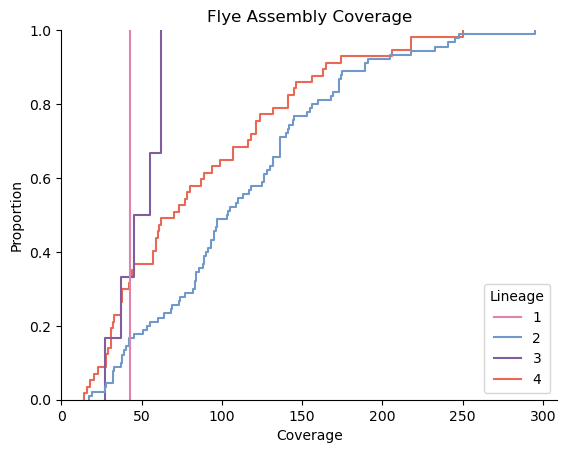

In [5]:
ax = sns.ecdfplot(
    data=df_assemblies_QC,
    x='Flye_Cov',
    hue='Lineage',
    palette=LinToColor_Dict,
    hue_order=np.sort(df_assemblies_QC['Lineage'].unique())
)

# Get the existing legend created by seaborn
sns.move_legend(ax, "lower right")

plt.title("Flye Assembly Coverage")
plt.xlabel('Coverage')

sns.despine()
plt.savefig("./figures/flye_coverage.svg", bbox_inches='tight')

In [6]:
df_assemblies_QC.query("Lineage=='1'")

,SampleID,ASM,PacBio_FQ_PATH,ASM_SampleID,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,Lineage
24,MFS-520,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-520,T0017,S0017-01,1,4429510.0,43,1.1.2,1.1.2,0,MFS-520,MFS-520,0.019246,1.1.2,1


# 2. Selecting the F2 threshold: Show number of low-AF variants (before LMM) vs. F2

In [3]:
all_samples = os.listdir(H37Rv_ref_dir)
len(all_samples)

767

In [4]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [5]:
df_lowAF_SNPs = []

for i, sample in enumerate(all_samples):
    
    df = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")

    df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df_lowAF_SNPs.append(df.query("REF.str.len() == ALT.str.len()"))

df_lowAF_SNPs = pd.concat(df_lowAF_SNPs).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Lineage', 'Coll2014']], how='left')
df_lowAF_SNPs['Region'] = df_lowAF_SNPs['POS'].map(h37Rv_coords_dict)

# the weird one caused by SNVs in close proximity having their AO values averaged
df_lowAF_SNPs = df_lowAF_SNPs.query("POS not in [4266668, 329923]")

df_lowAF_SNPs_summary = pd.DataFrame(df_lowAF_SNPs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

df_lowAF_SNPs_summary = pd.concat([df_lowAF_SNPs_summary,
                                   df_trust_patients.dropna(subset='Lineage').query("SampleID not in @df_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2', 'Lineage', 'Coll2014']]
                                ])

df_lowAF_SNPs_summary['NumSNPs'] = df_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

In [16]:
unmixed_samples = df_lowAF_SNPs_summary.query("F2 <= @F2_max").SampleID.unique()

In [6]:
df_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'].sum()

4294

In [7]:
df_lowAF_SNPs.query("POS >= 2338065 & POS <= 2340874").POS.nunique()

13

In [17]:
df_lowAF_SNPs.query("POS==2338866 & SampleID in @ground_truth_samples & SampleID in @unmixed_samples")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF']]

,pid,SampleID,POS,REF,ALT,AF
439,T0225,MFS-135,2338866,T,G,0.270570
1645,T0030,MFS-15,2338866,T,G,0.298206
16952,T0013,MFS-5,2338866,T,G,0.290196
17212,T0073,MFS-557,2338866,T,G,0.330827
17253,T0097,MFS-566,2338866,T,G,0.346591
24179,T0096,MFS-737,2338866,T,G,0.264599


In [20]:
df_assemblies_QC.query("SampleID=='MFS-135'").ASM.values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBio_Illumina_hybridASM/S0225-01/FlyeAssembly_I3_PilonPolishing/pilon_IllPE_Polishing_I3_Asm_ChangeSNPsINDELsOnly/S0225-01.Flye.I3Asm.PilonPolished.fasta'

In [21]:
df_liftoff = pd.read_csv(f"{personal_ref_dir}/MFS-135/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#')

In [23]:
df_liftoff.loc[df_liftoff[8].str.contains('Rv2082')]

,0,1,2,3,4,5,6,7,8
4259,S0225-01_contig_1_pilon,Liftoff,gene,2357357,2359441,.,+,.,ID=gene-Rv2082;Dbxref=GeneID:887795;Name=Rv208...
4260,S0225-01_contig_1_pilon,Liftoff,CDS,2357357,2359441,.,+,.,ID=cds-NP_216598.1;Parent=gene-Rv2082;Dbxref=G...


In [25]:
df_liftoff.iloc[4257:4265]

,0,1,2,3,4,5,6,7,8
4257,S0225-01_contig_1_pilon,Liftoff,gene,2356714,2357153,.,-,.,ID=gene-Rv2081c;Dbxref=GeneID:887348;Name=Rv20...
4258,S0225-01_contig_1_pilon,Liftoff,CDS,2356714,2357153,.,-,.,ID=cds-NP_216597.1;Parent=gene-Rv2081c;Dbxref=...
4259,S0225-01_contig_1_pilon,Liftoff,gene,2357357,2359441,.,+,.,ID=gene-Rv2082;Dbxref=GeneID:887795;Name=Rv208...
4260,S0225-01_contig_1_pilon,Liftoff,CDS,2357357,2359441,.,+,.,ID=cds-NP_216598.1;Parent=gene-Rv2082;Dbxref=G...
4261,S0225-01_contig_1_pilon,Liftoff,gene,2362180,2363124,.,+,.,ID=gene-Rv2083;Dbxref=GeneID:887281;Name=Rv208...
4262,S0225-01_contig_1_pilon,Liftoff,CDS,2362180,2363124,.,+,.,ID=cds-NP_216599.1;Parent=gene-Rv2083;Dbxref=G...
4263,S0225-01_contig_1_pilon,Liftoff,gene,2363117,2364264,.,+,.,ID=gene-Rv2084;Dbxref=GeneID:887350;Name=Rv208...
4264,S0225-01_contig_1_pilon,Liftoff,CDS,2363117,2364264,.,+,.,ID=cds-NP_216600.1;Parent=gene-Rv2084;Dbxref=G...


In [26]:
2362180-2359441

2739

In [ ]:
bcftools filter -i "POS >= 2356714 & POS < 2362180"

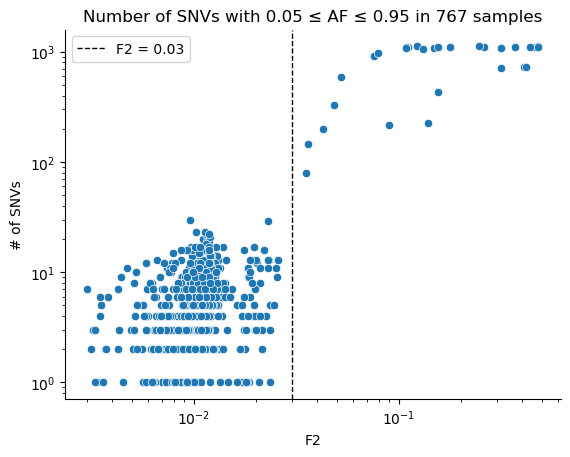

In [30]:
sns.scatterplot(data=df_lowAF_SNPs_summary,
                x='F2',
                y='NumSNPs',
               )

plt.ylabel('# of SNVs')
plt.title(f'Number of SNVs with 0.05 ≤ AF ≤ 0.95 in {df_lowAF_SNPs_summary.SampleID.nunique()} samples')

plt.xscale('log')
plt.yscale('log')

plt.axvline(F2_max, linestyle='--', color='black', linewidth=1, label=f'F2 = {F2_max}')
plt.legend()

sns.despine()
plt.savefig("./figures/lowAF_SNVs_vs_F2_pre_LMM.svg", bbox_inches='tight')

In [33]:
df_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts().head(10)

Region
Rv3433c    490
Rv2082     394
Rv2319c    368
uspC       234
pks15      145
ltp4        71
mmpS1       68
cyp138      58
Rv2081c     58
Rv1637c     46
Name: count, dtype: int64

In [5]:
len(df_lowAF_SNPs.query("F2 <= @F2_max"))

4331

In [11]:
len(df_validation)

3385

In [34]:
df_validation.pred_class.value_counts()

pred_class
1    2048
0    1313
Name: count, dtype: int64

In [35]:
df_validation.pred_class.mean()

0.6093424576019042

In [301]:
df_lowAF_SNPs.query("Region=='Rv2319c'")[['SampleID', 'POS', 'AF', 'AO', 'DP']].POS.unique()

array([2592310, 2591982, 2592270, 2592579], dtype=object)

# 3. Number of low-AF SNVs per Hybrid Assembly

In [53]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [13]:
# for sample in ground_truth_samples:
#     for fName in glob.glob(f"{personal_ref_dir}/{sample}/lowAF_comparison/*"):
#         os.rename(fName, fName.replace('.csv', '.old.csv'))

In [76]:
df_ground_truth_lowAF_SNPs = []

for i, sample in enumerate(ground_truth_samples):
    
    # df = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
    df = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.bed", sep='\t')
    # break

    df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df_ground_truth_lowAF_SNPs.append(df.query("REF.str.len() == ALT.str.len()"))

df_ground_truth_lowAF_SNPs = pd.concat(df_ground_truth_lowAF_SNPs).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_ground_truth_lowAF_SNPs['SameSample'] = df_ground_truth_lowAF_SNPs['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)
# df_ground_truth_lowAF_SNPs['Region'] = df_ground_truth_lowAF_SNPs['POS'].map(h37Rv_coords_dict)

df_ground_truth_lowAF_SNPs_summary = pd.DataFrame(df_ground_truth_lowAF_SNPs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

df_ground_truth_lowAF_SNPs_summary = pd.concat([df_ground_truth_lowAF_SNPs_summary,
                                              df_trust_patients.query("SampleID in @ground_truth_samples & SampleID not in @df_ground_truth_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
                                             ])

df_ground_truth_lowAF_SNPs_summary['NumSNPs'] = df_ground_truth_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

df_ground_truth_lowAF_SNPs_summary['SameSample'] = df_ground_truth_lowAF_SNPs_summary['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)

In [80]:
df_ground_truth_lowAF_SNPs.query("SAF < 5 & SAR < 5")

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR,SampleID,pid,F2,SameSample
18,S0195-06_contig_1_pilon,2477516,2477517,2477517,A,C,4616.0,PASS,178,178,...,0,0.056180,10,33.200000,4.0,3.0,MFS-110,T0195,0.009323,1
58,S0220-08_contig_1_pilon,4387693,4387694,4387694,G,C,4774.0,PASS,187,199,...,2,0.058824,11,25.909091,4.0,2.0,MFS-129,T0220,0.009631,0
141,S0255-01_contig_1_pilon,1537156,1537157,1537157,A,G,10438.0,PASS,367,393,...,0,0.051771,19,34.000000,4.0,3.0,MFS-171,T0255,0.008836,1
171,S0299-01_contig_1_pilon,1977994,1977995,1977995,G,A,7019.0,PASS,299,308,...,1,0.050167,15,26.117647,4.0,3.0,MFS-259,T0299,0.011203,1
175,S0290-01_contig_1_pilon,1979173,1979174,1979174,G,T,4485.0,PASS,187,195,...,0,0.058824,11,24.900000,2.0,2.0,MFS-264,T0290,0.013014,1
178,S0290-08_contig_1_pilon,1979173,1979174,1979174,G,T,4739.0,PASS,198,206,...,0,0.055556,11,24.400000,2.0,2.0,MFS-266,T0290,0.012428,1
227,S0292-08_contig_1_pilon,1978967,1978968,1978968,A,G,4344.0,PASS,164,173,...,2,0.054878,9,30.333333,3.0,2.0,MFS-311,T0292,0.010974,1
228,S0292-08_contig_1_pilon,1978970,1978971,1978971,C,G,4039.0,PASS,168,177,...,5,0.059524,10,27.500000,2.0,3.0,MFS-311,T0292,0.010974,1
2944,S0282-02_contig_1_pilon,1980538,1980539,1980539,G,T,5112.0,PASS,199,214,...,0,0.050251,10,21.533333,3.0,2.0,MFS-323,T0282,0.011942,1
2957,S0284-07_contig_1_pilon,1643520,1643521,1643521,A,T,4742.0,PASS,210,223,...,1,0.052381,11,21.666667,2.0,2.0,MFS-326,T0284,0.013818,1


In [83]:
df_ground_truth_lowAF_SNPs.query("SampleID=='MFS-754'")

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR,SampleID,pid,F2,SameSample
9106,S0191-01_contig_1_pilon,3889220,3889221,3889221,A,G,821.0,Amb,166,180,...,1,0.280000,46,38.800000,4.0,32.0,MFS-754,T0191,0.008959,1
9107,S0191-01_contig_1_pilon,3889221,3889222,3889222,C,T,825.0,Amb,167,181,...,0,0.280000,45,39.157895,4.0,31.0,MFS-754,T0191,0.008959,1
9108,S0191-01_contig_1_pilon,3889225,3889226,3889226,A,G,7.0,Amb,153,167,...,5,0.250000,39,37.428571,4.0,31.0,MFS-754,T0191,0.008959,1
9109,S0191-01_contig_1_pilon,3889257,3889258,3889258,C,T,990.0,Amb,137,143,...,0,0.300000,46,40.000000,3.0,43.0,MFS-754,T0191,0.008959,1
9110,S0191-01_contig_1_pilon,3889904,3889905,3889905,C,G,3310.0,Amb,142,150,...,0,0.400000,48,39.659574,35.0,10.0,MFS-754,T0191,0.008959,1
9111,S0191-01_contig_1_pilon,3889916,3889917,3889917,C,T,3262.0,Amb,137,145,...,1,0.400000,46,39.384615,37.0,12.0,MFS-754,T0191,0.008959,1
9112,S0191-01_contig_1_pilon,3889917,3889918,3889918,A,G,3433.0,Amb,138,145,...,1,0.410000,47,39.698113,37.0,14.0,MFS-754,T0191,0.008959,1
9113,S0191-01_contig_1_pilon,4175472,4175473,4175473,G,A,5415.0,PASS,237,237,...,0,0.105485,25,40.000000,13.0,12.0,MFS-754,T0191,0.008959,1


In [85]:
df_ground_truth_lowAF_SNPs.query("SampleID=='MFS-754'").query("SAF >= 5 & SAR >= 5")

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR,SampleID,pid,F2,SameSample
9110,S0191-01_contig_1_pilon,3889904,3889905,3889905,C,G,3310.0,Amb,142,150,...,0,0.400000,48,39.659574,35.0,10.0,MFS-754,T0191,0.008959,1
9111,S0191-01_contig_1_pilon,3889916,3889917,3889917,C,T,3262.0,Amb,137,145,...,1,0.400000,46,39.384615,37.0,12.0,MFS-754,T0191,0.008959,1
9112,S0191-01_contig_1_pilon,3889917,3889918,3889918,A,G,3433.0,Amb,138,145,...,1,0.410000,47,39.698113,37.0,14.0,MFS-754,T0191,0.008959,1
9113,S0191-01_contig_1_pilon,4175472,4175473,4175473,G,A,5415.0,PASS,237,237,...,0,0.105485,25,40.000000,13.0,12.0,MFS-754,T0191,0.008959,1


In [64]:
df_freebayes = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")

In [68]:
df.query("MQ >= 60")

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,MQ,BC,IC,DC,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR
1,S0004-01_contig_1_pilon,2062113,2062114,2062114,A,G,6015.0,PASS,255,256,...,60,"236,0,19,0",0,0,0,0.07451,19,32.5,7.0,11.0


In [69]:
df_freebayes.query("REF.str.len() == ALT.str.len()")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
1,2076862,A,G,1.100000e-14,NaN,257,239,18,0.070039,60.0,...,115,124,7,11,3.74624,4.9405,4.9405,18.2833,7.0,11.0


In [75]:
df_ground_truth_lowAF_SNPs.query("MQM < 60").MQM.min()

48.2658

In [30]:
df_ground_truth_lowAF_SNPs.query("SampleID=='MFS-520'")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAP,RPP,RPPR,RPL,RPR,SampleID,pid,F2,SameSample,Region
4261,675974,C,A,0.0,NaN,268,253,15,0.05597,60.0,...,4.31318,4.31318,39.273,6.0,9.0,MFS-520,T0017,0.019246,1,NC_461


In [8]:
df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= @F2_max").Lineage.value_counts()

Lineage
2    99
4    66
3     6
1     1
Name: count, dtype: int64

In [9]:
len(df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= @F2_max"))

172

In [15]:
len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").query("NumSNPs==0")) / len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max"))

0.26744186046511625

In [17]:
200/738

0.27100271002710025

In [16]:
len(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max"))

172

In [19]:
df_ground_truth_lowAF_SNPs_summary.SameSample.value_counts()

SameSample
1    154
0     25
Name: count, dtype: int64

In [20]:
df_ground_truth_lowAF_SNPs.query("POS in @rRNA_pos & F2 <= 0.03")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAP,RPP,RPPR,RPL,RPR,SampleID,pid,F2,SameSample,Region


In [21]:
df_ground_truth_lowAF_SNPs.query("POS in @insertion_seqs_phages_pos & F2 <= 0.03")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAP,RPP,RPPR,RPL,RPR,SampleID,pid,F2,SameSample,Region


In [57]:
# NC_9 = between Rv0010c and Rv0011c. Max sent me a paper about that variant
# NC_2982 = between whiB6 and Rv3863
pd.DataFrame(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts()).query("count > 2")

,count
Region,
sugI,8
subI,7
Rv3220c,6
devS,5
katG,4
PPE50,4
mbtE,3
Rv1680,3
NC_9,3


In [305]:
pd.DataFrame(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts())['count'].sum()

396

In [304]:
len(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max"))

396

In [278]:
df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max")[['Region', 'POS']].value_counts().sort_values(ascending=False)

Region  POS    
sugI    3717219    4
phoR    852970     2
Rv1049  1172492    2
Rv1171  1301452    2
lppM    2433614    2
                  ..
udgA    390330     1
ugpA    3141768    1
thrS    2941828    1
uvrA    1844169    1
yrbE4B  3919550    1
Name: count, Length: 354, dtype: int64

In [253]:
df_ground_truth_lowAF_SNPs_summary.query("SameSample==1 & F2 > 0.03")

,pid,SampleID,F2,NumSNPs,SameSample
52,T0198,MFS-377,0.108434,1083,1
132,T0427,MFS-696,0.108637,1012,1


In [254]:
df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").SameSample.value_counts()

SameSample
1    152
0     20
Name: count, dtype: int64

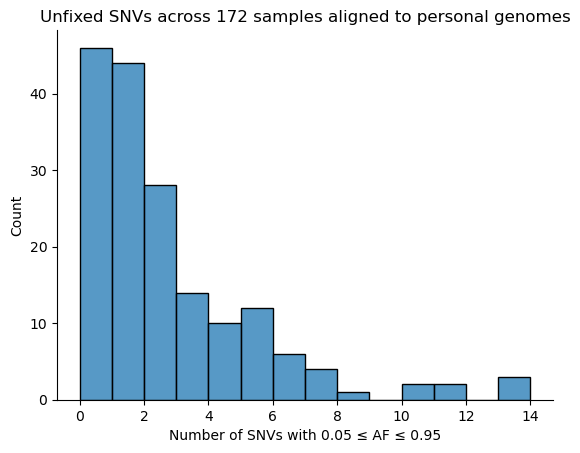

In [255]:
df_plot = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")

sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() + 1),
            )

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to personal genomes")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

sns.despine()
plt.savefig("./figures/personal_genome_lowAF_counts_dist.svg", bbox_inches='tight')

In [124]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_ground_truth_lowAF_SNPs_summary.query("SameSample==1 & F2 <= @F2_max")['NumSNPs'],
            alternative='two-sided'
           )

KstestResult(statistic=0.01744186046511628, pvalue=0.9999999999999997, statistic_location=3, statistic_sign=1)

In [49]:
min_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.min()
max_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.max()
median_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.median()
mean_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 14
Median: 1.0
Mean: 2.302325581395349


# 4. Compare number of unfixed SNVs between ground truth and H37Rv alignments

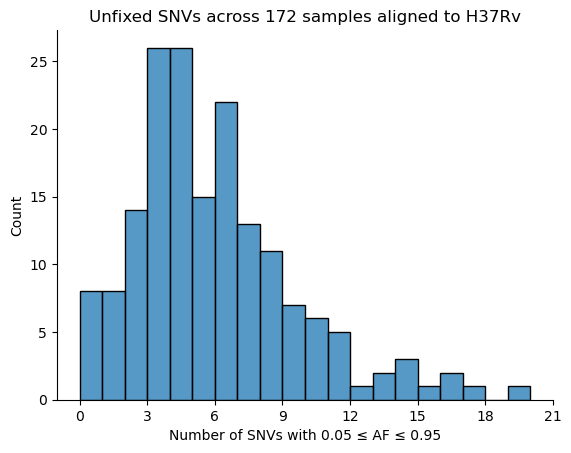

In [44]:
df_plot = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID")
              
sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() +1),
            )

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

ax = plt.gca()

# Force integer ticks
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_initial_dist_ground_truth.svg", bbox_inches='tight')

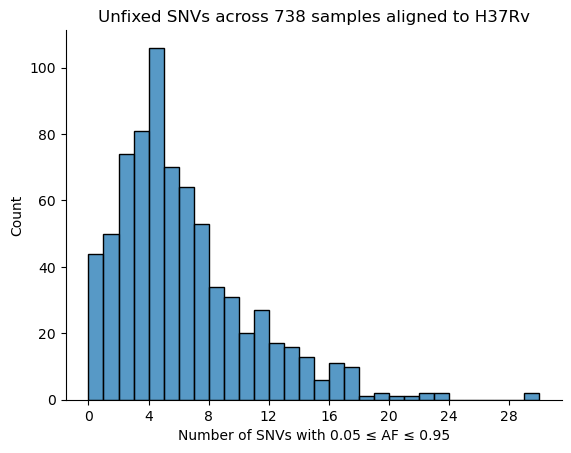

In [31]:
df_plot = df_lowAF_SNPs_summary.query("F2 <= @F2_max")# & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID")
              
sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() +1),
            )

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

ax = plt.gca()

# Force integer ticks
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_initial_dist.svg", bbox_inches='tight')

In [32]:
min_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID").NumSNPs.min()
max_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID").NumSNPs.max()
median_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID").NumSNPs.median()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")

Min: 0
Max: 20
Median: 5.0


In [35]:
df_compare_ground_truth_H37Rv = df_ground_truth_lowAF_SNPs_summary.merge(df_lowAF_SNPs_summary.query("F2 <= @F2_max").rename(columns={'NumSNPs': 'NumSNPs_H37Rv', 'NumIndels': 'NumIndels_H37Rv'}), on=['SampleID', 'pid', 'F2'])

df_compare_ground_truth_H37Rv['Difference'] = df_compare_ground_truth_H37Rv['NumSNPs_H37Rv'] - df_compare_ground_truth_H37Rv['NumSNPs']

min_val = df_compare_ground_truth_H37Rv.Difference.min()
max_val = df_compare_ground_truth_H37Rv.Difference.max()
median_val = df_compare_ground_truth_H37Rv.Difference.median()
mean_val = df_compare_ground_truth_H37Rv.Difference.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 19
Median: 3.0
Mean: 3.197674418604651


In [36]:
st.wilcoxon(df_compare_ground_truth_H37Rv['NumSNPs'],
            df_compare_ground_truth_H37Rv['NumSNPs_H37Rv']
           )

WilcoxonResult(statistic=0.0, pvalue=1.1947281148996226e-26)

In [52]:
df_compare_ground_truth_H37Rv.NumSNPs.sum(), df_compare_ground_truth_H37Rv.NumSNPs_H37Rv.sum()

(396, 946)

In [2]:
model_dir = "../lowAF_variant_calling/variantDetector/unmixed_only"

df_train = pd.read_csv(f"{model_dir}/training_data_with_predictions_fixed_effects_only.csv")

In [3]:
len(df_train.query("pred_class==1 & Real==0")), len(df_train.query("pred_class==1 & Real==0 & POS >= 2338065 & POS <= 2340874"))

(88, 33)

In [7]:
df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)").GENE.value_counts()

GENE
Rv3517             4
cyp138             4
Rv3900c            3
Rv3689             3
Rv1566c-Rv1567c    3
ltp4               3
PPE53              2
rplU-dctA          2
Rv0051-Rv0052      2
fusA2              1
Rv0457c            1
Rv1205             1
rmlC               1
sugI               1
ponA2              1
pks15              1
Rv1815             1
eccC2              1
Rv0837c-lpqR       1
Rv1719             1
dnaB-Rv0059        1
Rv2912c            1
Rv3822             1
Rv3726             1
tcrX               1
rnhB               1
cyp144             1
Rv0845-Rv0846c     1
coaA-MTS0858       1
espE               1
Rv3196A-Rv3197     1
pknH               1
Rv1937             1
Rv2749             1
Rv3843c            1
PPE9               1
Rv1794-eccD5       1
Rv1700             1
Name: count, dtype: int64

In [9]:
df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)").query("GENE=='cyp138'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF']]

,pid,SampleID,POS,REF,ALT,AF
653,T0085,MFS-52,163705,C,T,0.949791
654,T0085,MFS-52,163706,C,T,0.949791
674,T0100,MFS-55,163705,C,T,0.940945
675,T0100,MFS-55,163706,C,T,0.940945


In [15]:
df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)").query("SampleID=='MFS-520'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'predicted']]

,pid,SampleID,POS,REF,ALT,AF,GENE,predicted
658,T0017,MFS-520,1415097,C,G,0.537559,pknH,0.138161
660,T0017,MFS-520,3527982,G,C,0.201794,PPE53,0.094208
661,T0017,MFS-520,3527991,G,A,0.154185,PPE53,0.020694
662,T0017,MFS-520,3566943,A,G,0.135693,Rv3196A-Rv3197,0.052063
663,T0017,MFS-520,4341402,T,C,0.112628,espE,0.444688
664,T0017,MFS-520,4385897,T,C,0.256024,Rv3900c,0.016916
665,T0017,MFS-520,4385916,C,G,0.260652,Rv3900c,0.023416
666,T0017,MFS-520,4385937,C,T,0.710997,Rv3900c,0.086425


In [21]:
df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)")[['SampleID', 'Coll2014']].value_counts()

SampleID  Coll2014
MFS-520   1.1.2       8
MFS-753   2.2.1.1     8
MFS-737   3.1.1       7
MFS-754   4.1.1.1     5
MFS-768   2.2.1.1     4
MFS-310   4.8         3
MFS-755   4.1.1.1     3
MFS-307   4.1.1.1     2
MFS-52    2.2.1.1     2
MFS-55    2.2.1       2
MFS-160   4.3.2.1     1
MFS-877   4.1.1.1     1
MFS-767   4.1.1.1     1
MFS-756   2.2.1       1
MFS-557   3.1.1       1
MFS-741   4.1.2.1     1
MFS-27    4.8         1
MFS-411   4.3.2.1     1
MFS-395   4.1.1.1     1
MFS-28    4.1.1.1     1
MFS-878   4.1.1.3     1
Name: count, dtype: int64

MFS-753: all are fixed variants that have low AF caused by freebayes' nonsense
MFS-737: all are fixed
MFS-520: All false due to structural variants. 

In [32]:
df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)").query("SampleID=='MFS-754'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'Mean_BQ_ALT_allele', 'COV', 'COV_MAX_ROLLING_AVG',
       'CLIPPED_BASES', 'DISCORDANT_READS', 'COV_RATIO',
       'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO',
       'SAF_prop_deviation_from_half', 'Real',
       'False_in_all_Ground_Truth_Samples', 'predicted_fixed_effects',
       'predicted']]

,pid,SampleID,POS,REF,ALT,AF,GENE,Mean_BQ_ALT_allele,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples,predicted_fixed_effects,predicted
884,T0191,MFS-754,57393,A,T,0.940426,Rv0051-Rv0052,39.735537,243,270.61,1,1,0.897971,0.004115,0.004115,0.042986,0,1,0.999940,0.254452
886,T0191,MFS-754,2057774,A,T,0.936508,Rv1815,39.021277,282,276.48,2,0,1.019965,0.000000,0.007092,0.114407,0,1,0.999930,0.225212
887,T0191,MFS-754,3953969,G,T,0.805825,Rv3517,39.563981,213,233.66,0,3,0.911581,0.014085,0.000000,0.048193,0,1,0.999939,0.250866
888,T0191,MFS-754,3959418,C,T,0.916364,ltp4,38.936242,299,286.46,8,3,1.043776,0.010033,0.026756,0.051587,0,1,0.995427,0.004434
890,T0191,MFS-754,4379680,C,G,0.935780,eccC2,37.952000,251,257.29,1,3,0.975553,0.011952,0.003984,0.053922,0,1,0.999875,0.140641


In [36]:
df_FP_nonRv2082 = df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)")
len(df_FP_nonRv2082)

55

In [40]:
df_FP_lowAF = df_FP_nonRv2082.query("AF <= 0.1")
len(df_FP_lowAF)

4

In [41]:
df_FP_highAF = df_FP_nonRv2082.query("AF >= 0.8")
len(df_FP_highAF)

38

In [62]:
df_train.query("SampleID=='MFS-737' & Real==1")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,Freschi2020,Lineage,F2,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples,predicted_fixed_effects,predicted,pred_proba,pred_class
853,997899,C,T,4300.0,NaN,Rv0895,c.118C>T,p.Leu40Leu,1,329,...,3.1.1.i1,3,0.011066,0.068889,1,0,0.999332,0.043707,0.999332,1


<Axes: xlabel='SAF_prop_deviation_from_half', ylabel='Count'>

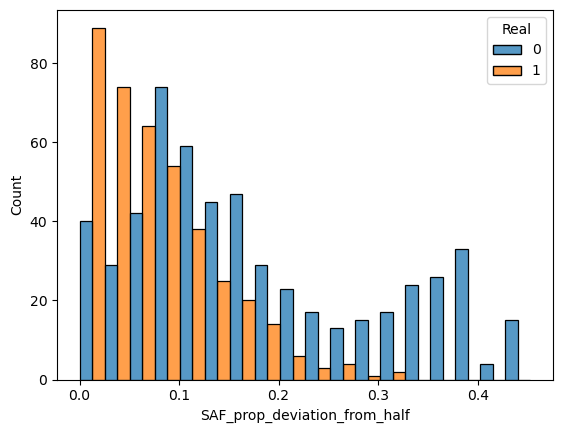

In [63]:
sns.histplot(data=df_train,#.query("pred_class==1 & Real==0"),
             x='SAF_prop_deviation_from_half',
             hue='Real',
             multiple='dodge'
            )

In [60]:
df_FP_nonRv2082.query("AF >= 0.8")[['SampleID', 'POS', 'AF']]

,SampleID,POS,AF
312,MFS-28,2032215,0.938596
520,MFS-395,3062615,0.943878
653,MFS-52,163705,0.949791
654,MFS-52,163706,0.949791
674,MFS-55,163705,0.940945
675,MFS-55,163706,0.940945
852,MFS-737,942616,0.945876
854,MFS-737,2010880,0.944272
863,MFS-737,2740693,0.941176
864,MFS-737,3212723,0.878706


In [44]:
L1_sample = df_FP_nonRv2082.query("AF > 0.1 & AF < 0.8").query("SampleID=='MFS-520'")
len(L1_sample)

8

In [48]:
df_FP_nonRv2082.query("AF > 0.1 & AF < 0.8").query("SampleID!='MFS-520'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'Mean_BQ_ALT_allele', 'COV', 'COV_MAX_ROLLING_AVG',
       'CLIPPED_BASES', 'DISCORDANT_READS', 'COV_RATIO',
       'DISCORDANT_READS_RATIO', 'CLIPPED_BASES_RATIO',
       'SAF_prop_deviation_from_half', 'Real',
       'False_in_all_Ground_Truth_Samples', 'predicted_fixed_effects',
       'predicted']]#.query("AF >= 0.1 & SampleID != 'MFS-520'").sort_values('AF')

,pid,SampleID,POS,REF,ALT,AF,GENE,Mean_BQ_ALT_allele,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO,SAF_prop_deviation_from_half,Real,False_in_all_Ground_Truth_Samples,predicted_fixed_effects,predicted
185,T0247,MFS-160,3717219,C,G,0.139073,sugI,32.130435,328,332.26,2,6,0.987179,0.018293,0.006098,0.119048,0,0,0.997381,0.715216
347,T0289,MFS-307,4316315,G,C,0.161017,Rv3843c,31.489362,263,308.85,0,6,0.851546,0.022814,0.000000,0.000000,0,1,0.998534,0.800130
370,T0292,MFS-310,4130682,A,G,0.320690,Rv3689,30.590909,328,314.13,5,5,1.044154,0.015244,0.015244,0.005376,0,1,0.993777,0.133610
371,T0292,MFS-310,4130683,T,C,0.320690,Rv3689,30.381818,327,313.72,5,5,1.042331,0.015291,0.015291,0.005376,0,1,0.993217,0.123878
372,T0292,MFS-310,4130694,T,C,0.324590,Rv3689,32.009346,344,309.99,0,5,1.109713,0.014535,0.000000,0.015152,0,1,0.999867,0.879158


In [49]:
df_samples = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")

In [57]:
df_samples.to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv", index=False)

In [13]:
df_train.query("pred_class==1 & Real==0 & ~(POS >= 2338065 & POS <= 2340874)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'predicted']].sort_values('AF')#.query("SampleID not in ['MFS-28', 'MFS-29', 'MFS-395']").shape

,pid,SampleID,POS,REF,ALT,AF,GENE,predicted
299,T0047,MFS-27,4211206,G,A,0.050193,tcrX,0.892252
584,T0338,MFS-411,2188876,T,C,0.050781,Rv1937,0.936935
682,T0073,MFS-557,1220275,C,T,0.052174,coaA-MTS0858,0.248737
340,T0289,MFS-307,467579,G,A,0.056738,PPE9,0.423340
663,T0017,MFS-520,4341402,T,C,0.112628,espE,0.444688
662,T0017,MFS-520,3566943,A,G,0.135693,Rv3196A-Rv3197,0.052063
185,T0247,MFS-160,3717219,C,G,0.139073,sugI,0.715216
661,T0017,MFS-520,3527991,G,A,0.154185,PPE53,0.020694
347,T0289,MFS-307,4316315,G,C,0.161017,Rv3843c,0.800130
660,T0017,MFS-520,3527982,G,C,0.201794,PPE53,0.094208


# 5. Number of SNVs before and after LMM 

In [5]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv.gz", compression='gzip')

    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # 4338594 is in the intergenic region between whiB6 and Rv3863. These I verified are real, but sometimes get predicted low quality
    # it was one of the false negatives in the training results, so I'm manually fixing it
    assert 4338594 in df_train_variants.POS.values
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0 & POS >= @first_pos & POS <= @last_pos & AF <= @AF_thresh").POS.values

        if len(false_lowAF_variant_sites) > 0:
            remove_pos = df_fixed_variants.query("pid==@pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh").POS.unique()
            
#             if len(remove_pos) > 0:
#                 print(pid, len(remove_pos))
            
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh)")
        
    # only apply the filter for classifier filter to low frequency variants
    df_val_variants = df_val_variants.query("(pred_class == 1 & POS >= @first_pos & POS <= @last_pos) | POS < @first_pos | POS > @last_pos")

    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    df_variants = pd.concat([df_train_variants, df_val_variants])

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    df_variants = df_variants.query("False_in_all_Ground_Truth_Samples==0").reset_index(drop=True)
    
    # add in the fixed variants. If Paired_Sample_Num is not in there, it means we took baseline only
    if 'Paired_Sample_Num' not in df_pids.columns:
        df_pids['Paired_Sample_Num'] = 1
        
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Paired_Sample_Num']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[df_variants['Region'].str.contains('NC'), 'Variant_Type'] = 'Intergenic'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # exclude genes Rv2081c and Rv2082. Very problematic for low frequency variant calling. But keep for fixed variants
    df_variants = df_variants.query("~(POS >= 2338065 & POS <= 2340874)")
    
    # There are two variants (POS = 4266664 and POS = 4266668) at different AFs. It averages them or something, bringing down the AF of 4266668
    # but it's actually fixed. So just exclude those manually. The 4266664 variant seems to be low quality
    # same thing for 329923 (POS = 329920 and 329923) at different AFs in L4.4.1.1 samples. The fixed one (329923) is probably a lineage marker
    df_variants = df_variants.query("POS not in [4266668, 329923]")
        
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [6]:
df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants("../lowAF_variant_calling/variantDetector/unmixed_only", df_trust_patients[['pid', 'SampleID', 'F2', 'Lineage']].dropna())

len(df_variants_baseline), len(df_lowAF_variants_baseline)

(719231, 1766)

In [16]:
df_lowAF_SNPs_filtered_summary = pd.DataFrame(df_lowAF_variants_baseline.groupby(['pid', 'SampleID', 'F2', 'Lineage'])['POS'].count()).reset_index().rename(columns={'POS': 'NumSNPs'})

samples_no_variants = list(set(df_trust_patients.dropna(subset='Lineage').SampleID) - set(df_lowAF_SNPs_filtered_summary.SampleID))

df_lowAF_SNPs_filtered_summary = pd.concat([df_lowAF_SNPs_filtered_summary,
                                            df_trust_patients.query("SampleID in @samples_no_variants")[['pid', 'SampleID', 'F2', 'Lineage']]
                                           ])

df_lowAF_SNPs_filtered_summary['NumSNPs'] = df_lowAF_SNPs_filtered_summary['NumSNPs'].fillna(0).astype(int)

df_lowAF_SNPs_compare = df_lowAF_SNPs_summary.query("F2 <= @F2_max")[['pid', 'SampleID', 'NumSNPs']].rename(columns={'NumSNPs': 'Before'}).merge(df_lowAF_SNPs_filtered_summary.rename(columns={'NumSNPs': 'After'}))

df_lowAF_SNPs_compare['Lineage'] = df_lowAF_SNPs_compare['Lineage'].astype(int).astype(str)
df_lowAF_SNPs_compare['Difference'] = df_lowAF_SNPs_compare['After'] - df_lowAF_SNPs_compare['Before']
df_lowAF_SNPs_compare['Prop_Difference'] = np.abs(df_lowAF_SNPs_compare['Difference']) / df_lowAF_SNPs_compare['Before']

print(len(df_lowAF_SNPs_compare))
df_lowAF_SNPs_compare.Lineage.value_counts(dropna=False)

738


Lineage
2    366
4    323
3     48
1      1
Name: count, dtype: int64

In [17]:
df_lowAF_SNPs_compare.Difference.max(), df_lowAF_SNPs_compare.Difference.median(), df_lowAF_SNPs_compare.Difference.mean()



(0, -3.0, -3.437669376693767)

In [18]:
len(df_lowAF_SNPs_compare.query("Before != 0")), df_lowAF_SNPs_compare.query("Before != 0").Prop_Difference.mean()



(694, 0.59861575869483)

In [19]:
len(df_lowAF_SNPs_compare.query("Before != 0")) / len(df_lowAF_SNPs_compare)

0.940379403794038

In [20]:
df_lowAF_SNPs_compare.Before.sum(), df_lowAF_SNPs_compare.After.sum()

(4303, 1766)

In [21]:
(df_lowAF_SNPs_compare.Before.sum() - df_lowAF_SNPs_compare.After.sum()) / df_lowAF_SNPs_compare.Before.sum()

0.5895886590750639

In [22]:
(df_lowAF_SNPs_compare.query("SampleID in @ground_truth_samples").Before.sum() - df_lowAF_SNPs_compare.query("SampleID in @ground_truth_samples").After.sum()) / df_lowAF_SNPs_compare.query("SampleID in @ground_truth_samples").Before.sum()

0.5835095137420718

In [23]:
min_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.min()
max_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.max()
median_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.median()
mean_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 30
Median: 5.0
Mean: 5.830623306233062


In [24]:
min_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.min()
max_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.max()
median_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.median()
mean_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 26
Median: 1.0
Mean: 2.392953929539295


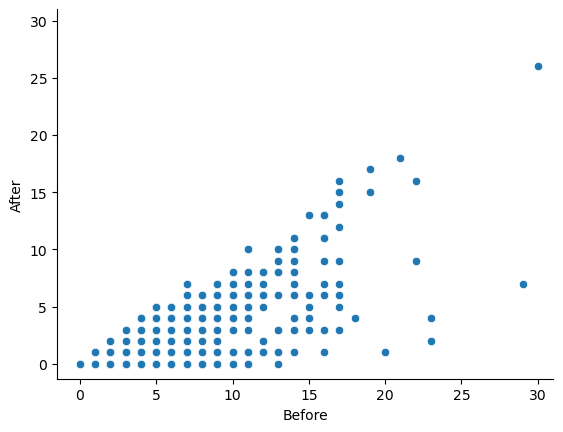

In [63]:
sns.scatterplot(data=df_lowAF_SNPs_compare,
                x='Before',
                y='After'
               )

max_val = df_lowAF_SNPs_compare[['Before', 'After']].max().max()

plt.xlim(right=max_val + 1)
plt.ylim(top=max_val + 1)

sns.despine()

<Axes: xlabel='Difference', ylabel='Proportion'>

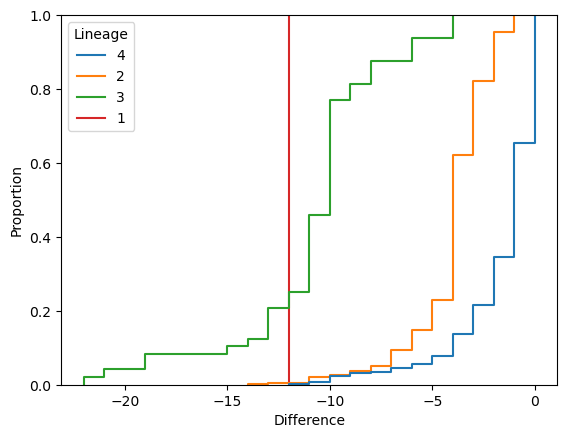

In [49]:
sns.ecdfplot(data=df_lowAF_SNPs_compare,
             x='Difference',
             hue='Lineage',
             # multiple='dodge'
            )

In [55]:
df_lowAF_SNPs_compare.Difference.median(), df_lowAF_SNPs_compare.Difference.mean()

(-3.0, -3.430894308943089)

In [56]:
df_lowAF_SNPs_compare.Difference.min(), df_lowAF_SNPs_compare.Difference.max()

(-22, 0)

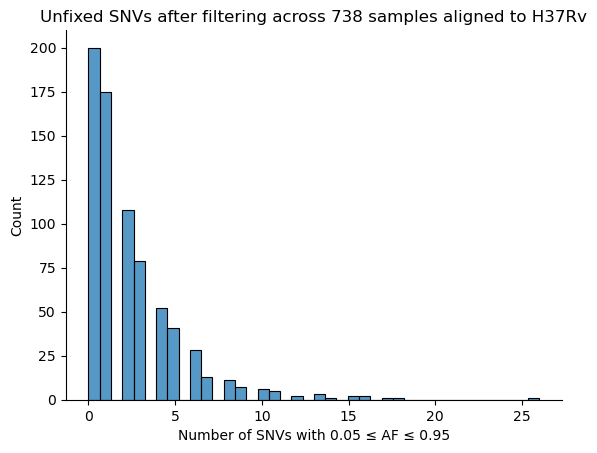

In [38]:
df_plot = df_lowAF_SNPs_compare.query("F2 <= @F2_max")

sns.histplot(data=df_plot,
             x='After'
            )

plt.title(f"Unfixed SNVs after filtering across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_final_dist.svg", bbox_inches='tight')

In [42]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_lowAF_SNPs_compare.query("F2 <= @F2_max")['Before']
           )

KstestResult(statistic=0.45840423520514273, pvalue=4.066227686884914e-27, statistic_location=2, statistic_sign=1)

In [43]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_lowAF_SNPs_compare.query("F2 <= @F2_max")['After']
           )

KstestResult(statistic=0.03157496691245982, pvalue=0.9982025576423489, statistic_location=2, statistic_sign=1)

In [61]:
len(df_lowAF_SNPs_compare.query("After==0")), len(df_lowAF_SNPs_compare)

(200, 738)

In [62]:
df_lowAF_variants_baseline.GENE.value_counts().head(10)

GENE
sugI       41
Rv2690c    19
devS       18
devR       18
phoR       15
Rv2781c    11
Rv0193c    11
subI       10
gcvB        9
ceoB        9
Name: count, dtype: int64

In [75]:
for gene in df_lowAF_variants_baseline.GENE.value_counts().index.values[:5]:
    print(gene, np.sort(df_lowAF_variants_baseline.query("GENE==@gene")['Lineage'].unique()))

sugI [2. 3. 4.]
Rv2690c [2. 4.]
devS [2. 3. 4.]
devR [2. 3. 4.]
phoR [2. 4.]


In [61]:
df_lowAF_variants_baseline.SNP.value_counts()

SNP
3717105_C_T    17
226517_C_T     10
329923_T_C      9
1208652_G_A     9
93313_C_T       8
               ..
2154800_A_G     1
2153995_G_T     1
1955265_C_G     1
3596606_T_C     1
1844169_G_T     1
Name: count, Length: 1476, dtype: int64

In [68]:
df_lowAF_variants_baseline.dropna(subset='HGVS_P').query("HGVS_P.str.contains('p.Pro7') & GENE=='sugI'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Real,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA
41,3717108,C,A,3.400000e+03,sugI,c.19C>A,p.Pro7Thr,1,259,259.0,...,1.0,0.0,0.997928,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
72,3717108,C,A,3.700000e+03,sugI,c.19C>A,p.Pro7Thr,1,299,299.0,...,1.0,0.0,0.974929,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
195,3717108,C,A,0.000000e+00,sugI,c.19C>A,p.Pro7Thr,1,338,338.0,...,NaN,0.0,0.995780,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
561,3717109,C,A,1.700000e+03,sugI,c.20C>A,p.Pro7His,1,258,258.0,...,NaN,0.0,0.993289,1.0,1,3717109_C_A,sugI,Missense,Pro,His
736,3717108,C,A,7.000000e-14,sugI,c.19C>A,p.Pro7Thr,1,227,227.0,...,NaN,0.0,0.980904,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
789,3717109,C,A,2.200000e-13,sugI,c.20C>A,p.Pro7His,1,291,291.0,...,NaN,0.0,0.997672,1.0,1,3717109_C_A,sugI,Missense,Pro,His
924,3717108,C,A,9.200000e-15,sugI,c.19C>A,p.Pro7Thr,1,218,218.0,...,NaN,0.0,0.997916,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
1369,3717109,C,A,4.500000e-14,sugI,c.20C>A,p.Pro7His,1,273,273.0,...,NaN,0.0,0.999715,1.0,1,3717109_C_A,sugI,Missense,Pro,His
1451,3717109,C,A,1.700000e-13,sugI,c.20C>A,p.Pro7His,1,425,425.0,...,NaN,0.0,0.999958,1.0,1,3717109_C_A,sugI,Missense,Pro,His
1716,3717108,C,A,6.800000e+01,sugI,c.19C>A,p.Pro7Thr,1,285,285.0,...,NaN,0.0,0.999266,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr


# 5. How many Ground Truth Variants could not be Transferred to H37Rv Coordinates?

Those in IS6110 elements will not be able to be transferred, so leave as is. 

Right now, there is one real variant that could not be transferred: 3717219 (sugI) in MFS-160. I don't know why it wasn't transferred. 

But there is no longitudinal sampling for this pid, so it's not a huge deal, and it's detected when aligning Illumina reads to H37Rv and the LMM predicts it as a real variant, so the signal is good. paftools.js liftover just fails.

In [2]:
def get_id_from_gtf_attribute(attr_string):
    """
    Extract the value of the ID field from a GTF/GFF attributes string.

    Example:
    attr_string = "ID=gene-Rv3324c;Dbxref=GeneID:887981;Name=moaC3;..."
    returns "gene-Rv3324c"
    """
    # Split by semicolon
    fields = attr_string.split(";")
    
    # Iterate through key=value pairs
    for f in fields:
        f = f.strip()
        if f.startswith("ID="):
            return f.split("=", 1)[1]  # split only on first '='
    
    # If no ID field found, return None
    return None

In [133]:
df_transferred_variants = pd.DataFrame(columns = ['SampleID', 'NumSNPs', 'NumSNPsTransferred'])

for i, sample in enumerate(os.listdir(personal_ref_dir)):
    
    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t').query("REF.str.len() == ALT.str.len()").drop_duplicates(subset=['POS', 'REF', 'ALT'])

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])
    
    if len(H37Rv_transferred_variants) > 0:
        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)
        
        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)
    else:
        num_transferred = 0
            
    df_transferred_variants.loc[i, :] = [sample, len(personal_genome_variants), num_transferred]
    
df_transferred_variants = df_transferred_variants.merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Coll2014']], on='SampleID', how='left')
assert sum(pd.isnull(df_transferred_variants['pid'])) == 0

In [134]:
search_samples = df_transferred_variants.query("F2 <= @F2_max & NumSNPs != NumSNPsTransferred").SampleID.values

for sample in search_samples:

    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t')#.query("REF.str.len() == ALT.str.len()")

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])

    if len(H37Rv_transferred_variants) > 0:

        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)

        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)

        missed_pos = list(set(personal_genome_variants.POS) - set(combined_variants.POS))

        # see if the variant was found when aligning to H37Rv. If it was, then we have a problem that we can fix. If it wasn't, then the region is just too different for paftools liftover to transfer it
        df_H37Rv_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")
        
        liftoff_gtf = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#',
                                  names=['Chrom', 'Source', 'Feature', 'Start', 'End', 'Score', 'Sense', 'Score2', 'Attribute']
                                 )
        
#         df_IS6110_elements = pd.read_csv(f"{personal_ref_dir}/{sample}/IS6110/{sample}.sam", header=None, sep='\t')
        
#         IS6110_pos = []
        
#         # IS6110 element is 1,355 bp long
#         for i, row in df_IS6110_elements.iterrows():
#             IS6110_pos += list(np.arange(row[3], row[3] + 1355))

        for pos in missed_pos:
            # min_distance = np.min(np.abs(np.array([pos]) - np.array(IS6110_pos)))
            AF = personal_genome_variants.query("POS==@pos").get('AF').values[0]
            # print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)} within {min_distance} bp of an IS6110 element")
            print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)}")
            
            within_gene = liftoff_gtf.query("Feature=='gene' & Start <= @pos & End >= @pos")
            
            if len(within_gene) > 0:
                gene = get_id_from_gtf_attribute(within_gene.Attribute.values[-1]).split('-')[-1]
                print(f"    Within {gene}")
            else:
                upstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("Feature=='gene' & Start <= @pos").Attribute.values[-1]).split('-')[-1]
                downstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("End >= @pos").Attribute.values[0]).split('-')[-1]
                print(f"    {upstream_gene}-{downstream_gene}")

MFS-160 has a missed position, 3725173 with AF = 0.1342
    Within Rv3331
MFS-26 has a missed position, 3719445 with AF = 0.244
    Rv3324c-Rv3327
MFS-321 has a missed position, 3711316 with AF = 0.3899
    Rv3324c-Rv3327
MFS-322 has a missed position, 3711316 with AF = 0.4315
    Rv3324c-Rv3327
MFS-4 has a missed position, 3708237 with AF = 0.2005
    Rv3324c-Rv3327


## pilon

In [33]:
del_fNames = glob.glob(f"{personal_ref_dir}/*/pilon/confusion_matrix.csv")
len(del_fNames)

179

In [34]:
# for fName in del_fNames:
#     os.remove(fName)

In [87]:
df_transferred_variants = pd.DataFrame(columns = ['SampleID', 'NumSNPs', 'NumSNPsTransferred'])

for i, sample in enumerate(os.listdir(personal_ref_dir)):
    
    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.bed", sep='\t').query("REF.str.len() == ALT.str.len() & SAF >= 5 & SAR >= 5").drop_duplicates(subset=['POS', 'REF', 'ALT'])

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])
    
    if len(H37Rv_transferred_variants) > 0:
        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)
        
        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)
    else:
        num_transferred = 0
            
    df_transferred_variants.loc[i, :] = [sample, len(personal_genome_variants), num_transferred]
    
df_transferred_variants = df_transferred_variants.merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Coll2014']], on='SampleID', how='left')
assert sum(pd.isnull(df_transferred_variants['pid'])) == 0

In [88]:
search_samples = df_transferred_variants.query("F2 <= @F2_max & NumSNPs != NumSNPsTransferred").SampleID.values

for sample in search_samples:

    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.bed", sep='\t').query("REF.str.len() == ALT.str.len() & SAF >= 5 & SAR >= 5")

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])

    if len(H37Rv_transferred_variants) > 0:

        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)

        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)

        missed_pos = list(set(personal_genome_variants.POS) - set(combined_variants.POS))

        # see if the variant was found when aligning to H37Rv. If it was, then we have a problem that we can fix. If it wasn't, then the region is just too different for paftools liftover to transfer it
        # df_H37Rv_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/pilon/lowAF_SNVs.csv")
        
        liftoff_gtf = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#',
                                  names=['Chrom', 'Source', 'Feature', 'Start', 'End', 'Score', 'Sense', 'Score2', 'Attribute']
                                 )
        
#         df_IS6110_elements = pd.read_csv(f"{personal_ref_dir}/{sample}/IS6110/{sample}.sam", header=None, sep='\t')
        
#         IS6110_pos = []
        
#         # IS6110 element is 1,355 bp long
#         for i, row in df_IS6110_elements.iterrows():
#             IS6110_pos += list(np.arange(row[3], row[3] + 1355))

        for pos in missed_pos:
            # min_distance = np.min(np.abs(np.array([pos]) - np.array(IS6110_pos)))
            AF = personal_genome_variants.query("POS==@pos").get('AF').values[0]
            # print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)} within {min_distance} bp of an IS6110 element")
            
            within_gene = liftoff_gtf.query("Feature=='gene' & Start <= @pos & End >= @pos")
            
            if len(within_gene) > 0:
                gene = get_id_from_gtf_attribute(within_gene.Attribute.values[-1]).split('-')[-1]
                
                # if gene in ['Rv3478', 'Rv3511', 'Rv3514', 'Rv1759c']:
                print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)}")
                print(f"    Within {gene}")
            else:
                upstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("Feature=='gene' & Start <= @pos").Attribute.values[-1]).split('-')[-1]
                downstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("End >= @pos").Attribute.values[0]).split('-')[-1]
                
                # if upstream_gene in ['Rv0978c']:
                print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)}")
                print(f"    {upstream_gene}-{downstream_gene}")

MFS-160 has a missed position, 3725173 with AF = 0.1325
    Within Rv3331
MFS-26 has a missed position, 3719445 with AF = 0.26
    Rv3324c-Rv3327
MFS-321 has a missed position, 3711316 with AF = 0.38
    Rv3324c-Rv3327
MFS-322 has a missed position, 3711316 with AF = 0.44
    Rv3324c-Rv3327
MFS-4 has a missed position, 3708237 with AF = 0.1964
    Rv3324c-Rv3327
MFS-754 has a missed position, 3889905 with AF = 0.4
    Within Rv3478
MFS-754 has a missed position, 3889917 with AF = 0.4
    Within Rv3478
MFS-754 has a missed position, 3889918 with AF = 0.41
    Within Rv3478


In [43]:
h37Rv_genes.query("H37rv_GeneID=='Rv0978c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
1004,1004,CDS,1093361,1094356,-,0.0,Rv0978c,PE_PGRS17,Function unknown,PE-PGRS family protein PE_PGRS17,...,Q79FU2,NaN,NaN,NaN,Mb1003c,NaN,NaN,NaN,NaN,NaN


In [50]:
sample

'MFS-754'

In [51]:
personal_genome_variants.sort_values('POS')

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,MQ,BC,IC,DC,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR
0,S0191-01_contig_1_pilon,3889220,3889221,3889221,A,G,821.0,Amb,166,180,...,41,"120,0,46,0",0,0,1,0.280000,46,38.800000,4.0,32.0
1,S0191-01_contig_1_pilon,3889221,3889222,3889222,C,T,825.0,Amb,167,181,...,40,"0,122,0,45",0,0,0,0.280000,45,39.157895,4.0,31.0
2,S0191-01_contig_1_pilon,3889225,3889226,3889226,A,G,7.0,Amb,153,167,...,41,"114,0,39,0",0,0,5,0.250000,39,37.428571,4.0,31.0
3,S0191-01_contig_1_pilon,3889257,3889258,3889258,C,T,990.0,Amb,137,143,...,45,"0,91,0,46",0,0,0,0.300000,46,40.000000,3.0,43.0
4,S0191-01_contig_1_pilon,3889904,3889905,3889905,C,G,3310.0,Amb,142,150,...,48,"0,94,48,0",0,0,0,0.400000,48,39.659574,35.0,10.0
5,S0191-01_contig_1_pilon,3889916,3889917,3889917,C,T,3262.0,Amb,137,145,...,47,"0,91,0,46",0,0,1,0.400000,46,39.384615,37.0,12.0
6,S0191-01_contig_1_pilon,3889917,3889918,3889918,A,G,3433.0,Amb,138,145,...,47,"91,0,47,0",0,0,1,0.410000,47,39.698113,37.0,14.0
7,S0191-01_contig_1_pilon,4175472,4175473,4175473,G,A,5415.0,PASS,237,237,...,60,"25,0,212,0",0,0,0,0.105485,25,40.000000,13.0,12.0


In [ ]:
personal_genome_variants

In [49]:
df_depth.query("POS in @personal_genome_variants.POS.values")

,CHROM,POS,DEPTH
3889220,S0191-01_contig_1_pilon,3889221,195
3889221,S0191-01_contig_1_pilon,3889222,194
3889225,S0191-01_contig_1_pilon,3889226,200
3889257,S0191-01_contig_1_pilon,3889258,155
3889904,S0191-01_contig_1_pilon,3889905,154
3889916,S0191-01_contig_1_pilon,3889917,157
3889917,S0191-01_contig_1_pilon,3889918,158
4175472,S0191-01_contig_1_pilon,4175473,272


In [47]:
df_depth.DEPTH.median() / 2

128.0

In [19]:
df_depth = pd.read_csv(f"{personal_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz", compression='gzip', sep='\t', names=['CHROM', 'POS', 'DEPTH'])

In [29]:
personal_genome_variants.merge(df_depth[['POS', 'DEPTH']])[['POS', 'REF', 'ALT', 'DP', 'DEPTH']].query("DP >= @min_depth")

,POS,REF,ALT,TD,DP,DEPTH
0,3889221,A,G,180,166,195
1,3889222,C,T,181,167,194
2,3889226,A,G,167,153,200
3,3889258,C,T,143,137,155
5,3889905,C,G,150,142,154
6,3889917,C,T,145,137,157
7,3889918,A,G,145,138,158
9,4175473,G,A,237,237,272


In [28]:
H37Rv_transferred_variants

,H37Rv_CHROM,H37Rv_BEG,H37Rv_END,Orig_Variant,Score,Sense,CHROM,BEG,END
0,Chromosome,4179211,4179212,S0191-01_contig_1_pilon_4175472_4175473,0,+,S0191-01_contig_1_pilon,4175472,4175473
1,Chromosome,3894587,3894588,S0191-01_contig_1_pilon_3889220_3889221,0,+,S0191-01_contig_1_pilon,3889220,3889221
2,Chromosome,3894588,3894589,S0191-01_contig_1_pilon_3889221_3889222,0,+,S0191-01_contig_1_pilon,3889221,3889222
3,Chromosome,3894592,3894593,S0191-01_contig_1_pilon_3889225_3889226,0,+,S0191-01_contig_1_pilon,3889225,3889226
4,Chromosome,3894624,3894625,S0191-01_contig_1_pilon_3889257_3889258,0,+,S0191-01_contig_1_pilon,3889257,3889258
5,Chromosome,3894677,3894678,S0191-01_contig_1_pilon_3889310_3889311,0,+,S0191-01_contig_1_pilon,3889310,3889311


In [25]:
min_depth = df_depth.DEPTH.median() / 2

In [26]:
min_depth

128.0

In [73]:
H37Rv_transferred_variants.sort_values('H37Rv_BEG')

,H37Rv_CHROM,H37Rv_BEG,H37Rv_END,Orig_Variant,Score,Sense,CHROM,BEG,END
0,Chromosome,3649035,3649036,S0242-08_contig_1_pilon_3639122_3639123,0,+,S0242-08_contig_1_pilon,3639122,3639123
1,Chromosome,3894475,3894476,S0242-08_contig_1_pilon_3889864_3889865,0,+,S0242-08_contig_1_pilon,3889864,3889865
2,Chromosome,3894624,3894625,S0242-08_contig_1_pilon_3890013_3890014,0,+,S0242-08_contig_1_pilon,3890013,3890014
3,Chromosome,3894677,3894678,S0242-08_contig_1_pilon_3890066_3890067,0,+,S0242-08_contig_1_pilon,3890066,3890067
4,Chromosome,3894724,3894725,S0242-08_contig_1_pilon_3890113_3890114,0,+,S0242-08_contig_1_pilon,3890113,3890114
5,Chromosome,3894731,3894732,S0242-08_contig_1_pilon_3890120_3890121,0,+,S0242-08_contig_1_pilon,3890120,3890121


In [76]:
personal_genome_variants.sort_values('POS')

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,MQ,BC,IC,DC,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR
0,S0242-08_contig_1_pilon,3639122,3639123,3639123,G,A,6910.0,PASS,398,398,...,60,"47,0,350,1",0,0,0,0.11809,47,33.037037,23.0,24.0
1,S0242-08_contig_1_pilon,3889864,3889865,3889865,C,T,9613.0,PASS,394,397,...,58,"0,368,0,26",0,0,0,0.06599,26,33.750000,12.0,12.0
2,S0242-08_contig_1_pilon,3890013,3890014,3890014,C,T,2680.0,Amb,267,274,...,49,"0,165,1,101",0,0,1,0.32000,101,33.425532,24.0,64.0
3,S0242-08_contig_1_pilon,3890066,3890067,3890067,G,C,1926.0,Amb,203,267,...,47,"0,122,81,0",0,0,5,0.68000,122,32.910569,20.0,84.0
4,S0242-08_contig_1_pilon,3890113,3890114,3890114,G,A,946.0,Amb,127,238,...,45,"83,0,44,0",0,0,0,0.69000,83,33.076923,4.0,76.0
5,S0242-08_contig_1_pilon,3890120,3890121,3890121,G,A,1303.0,Amb,105,229,...,43,"64,0,40,1",0,0,4,0.66000,64,33.417722,3.0,71.0
6,S0242-08_contig_1_pilon,3890588,3890589,3890589,G,A,1863.0,Amb,58,312,...,45,"26,0,32,0",0,0,4,0.50000,26,32.206897,24.0,2.0
7,S0242-08_contig_1_pilon,3890592,3890593,3890593,G,A,1756.0,Amb,62,318,...,45,"28,0,34,0",0,0,16,0.48000,28,29.266667,19.0,2.0
8,S0242-08_contig_1_pilon,3890620,3890621,3890621,T,A,2581.0,Amb,99,341,...,45,"49,0,0,50",0,0,0,0.56000,49,33.851852,51.0,2.0
9,S0242-08_contig_1_pilon,3890657,3890658,3890658,C,G,3253.0,Amb,117,377,...,44,"0,60,57,0",0,0,0,0.54000,57,34.000000,56.0,2.0


In [43]:
combined_variants

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,Mean_BQ_ALT_allele,SAF,SAR,H37Rv_CHROM,H37Rv_BEG,H37Rv_END,Orig_Variant,Score,Sense,H37Rv_POS
0,S0242-08_contig_1_pilon,3639122,3639123,3639123,G,A,6910.0,PASS,398,398,...,33.037037,23.0,24.0,Chromosome,3649035,3649036,S0242-08_contig_1_pilon_3639122_3639123,0,+,3649036


In [42]:
personal_genome_variants

,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,MQ,BC,IC,DC,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR
0,S0242-08_contig_1_pilon,3639122,3639123,3639123,G,A,6910.0,PASS,398,398,...,60,"47,0,350,1",0,0,0,0.11809,47,33.037037,23.0,24.0
1,S0242-08_contig_1_pilon,3889864,3889865,3889865,C,T,9613.0,PASS,394,397,...,58,"0,368,0,26",0,0,0,0.06599,26,33.750000,12.0,12.0
2,S0242-08_contig_1_pilon,3890013,3890014,3890014,C,T,2680.0,Amb,267,274,...,49,"0,165,1,101",0,0,1,0.32000,101,33.425532,24.0,64.0
3,S0242-08_contig_1_pilon,3890066,3890067,3890067,G,C,1926.0,Amb,203,267,...,47,"0,122,81,0",0,0,5,0.68000,122,32.910569,20.0,84.0
4,S0242-08_contig_1_pilon,3890113,3890114,3890114,G,A,946.0,Amb,127,238,...,45,"83,0,44,0",0,0,0,0.69000,83,33.076923,4.0,76.0
5,S0242-08_contig_1_pilon,3890120,3890121,3890121,G,A,1303.0,Amb,105,229,...,43,"64,0,40,1",0,0,4,0.66000,64,33.417722,3.0,71.0
6,S0242-08_contig_1_pilon,3890588,3890589,3890589,G,A,1863.0,Amb,58,312,...,45,"26,0,32,0",0,0,4,0.50000,26,32.206897,24.0,2.0
7,S0242-08_contig_1_pilon,3890592,3890593,3890593,G,A,1756.0,Amb,62,318,...,45,"28,0,34,0",0,0,16,0.48000,28,29.266667,19.0,2.0
8,S0242-08_contig_1_pilon,3890620,3890621,3890621,T,A,2581.0,Amb,99,341,...,45,"49,0,0,50",0,0,0,0.56000,49,33.851852,51.0,2.0
9,S0242-08_contig_1_pilon,3890657,3890658,3890658,C,G,3253.0,Amb,117,377,...,44,"0,60,57,0",0,0,0,0.54000,57,34.000000,56.0,2.0


In [22]:
H37Rv_transferred_variants_excludeLowConf

,H37Rv_CHROM,H37Rv_BEG,H37Rv_END,Orig_Variant,Score,Sense,CHROM,BEG,END
0,Chromosome,4179211,4179212,S0191-01_contig_1_pilon_4175472_4175473,0,+,S0191-01_contig_1_pilon,4175472,4175473


,CHROM,BEG,END,POS,REF,ALT,QUAL,FILTER,DP,TD,...,MQ,BC,IC,DC,XC,AF,AO,Mean_BQ_ALT_allele,SAF,SAR
0,S0191-01_contig_1_pilon,4175472,4175473,4175473,G,A,5415.0,PASS,237,237,...,60,"25,0,212,0",0,0,0,0.105485,25,40.0,13.0,12.0


In [10]:
H37Rv_transferred_variants_excludeLowConf = pd.read_csv(f"{personal_ref_dir}/{sample}/pilon/lowAF_SNVs.H37Rv.excludeLowConf.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])


In [ ]:
3894352	3895575

In [8]:
df_trust_patients.query("SampleID in ['MFS-754', 'MFS-151']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
127,T0191,S0191-01,MFS-754,MFS-754_lib73572,1.0,NaN,1.0,272.52,0.99,0.9839,...,12.0,31.0,1.0,0.470909,NaN,0.008959,4.1.1.1,4.1.i1.2.1,4,1
737,T0242,S0242-08,MFS-151,MFS-151_lib47330,NaN,NaN,1.0,443.75,1.00,0.9807,...,NaN,NaN,2.0,1.613880,NaN,0.005072,4.4.1.1,4.2.1.2.2.1.1,4,8


# F2 for Longitudinal Samples

In [80]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

325 pids
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.486153846153846


In [81]:
df_longitudinal_pids['Major_Lineage'] = np.nan
df_longitudinal_pids['Major_Lineage_Prop'] = np.nan
df_longitudinal_pids['Minor_Lineage'] = np.nan
df_longitudinal_pids['Minor_Lineage_Prop'] = np.nan

for i, row in df_longitudinal_pids.iterrows():
    
    pid = row['pid']
    sample = row['SampleID']
    
    if ',' in row['mix_phylotypes']:
        
        lineages = row['mix_phylotypes'].split(',')
        props = np.array(row['mix_props'].split(',')).astype(float)
        
        major_lineage = lineages[np.argmax(props)]
        major_prop = np.max(props)
        
    else:
        major_lineage = row['mix_phylotypes']
        major_prop = 1
    
    df_longitudinal_pids.loc[i, 'Major_Lineage'] = major_lineage
    df_longitudinal_pids.loc[i, 'Major_Lineage_Prop'] = major_prop
    
    if ',' in row['mix_phylotypes']:
        
        second_highest_idx = np.argpartition(props, -2)[-2]
        
        df_longitudinal_pids.loc[i, 'Minor_Lineage'] = lineages[second_highest_idx]
        df_longitudinal_pids.loc[i, 'Minor_Lineage_Prop'] = props[second_highest_idx]

df_longitudinal_pids['Major_Lineage'] = df_longitudinal_pids['Major_Lineage'].fillna(df_longitudinal_pids['Coll2014'])
df_longitudinal_pids['Major_Lineage_Prop'] = df_longitudinal_pids['Major_Lineage_Prop'].fillna(1)

df_longitudinal_pids['Major_Minor_Diff'] = df_longitudinal_pids['Major_Lineage_Prop'] - df_longitudinal_pids['Minor_Lineage_Prop']

In [82]:
pids_different_major_lineages = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['Major_Lineage'].nunique()).query("Major_Lineage > 1").index.values
print(f"{len(pids_different_major_lineages)} pids have discordant unmixed samples")

df_longitudinal_pids = df_longitudinal_pids.query("pid not in @pids_different_major_lineages").reset_index(drop=True)

# df_longitudinal_pids.query("pid in @pids_different_major_lineages")[['pid', 'Original_ID', 'mix_phylotypes', 'F2', 'mix_props', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop', 'Major_Minor_Diff']]

17 pids have discordant unmixed samples


In [83]:
df_longitudinal_pids.Sampling_Interval.median(), df_longitudinal_pids.Sampling_Interval.mean()

(6.0, 5.503246753246753)

In [84]:
same_lineages = []

pids_multiple_lineages = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes > 1").index.values

for pid in pids_multiple_lineages:
    
    sample_1_major_lineage = df_longitudinal_pids.query("pid == @pid & Paired_Sample_Num == 1").Major_Lineage.values[0]
    sample_2_major_lineage = df_longitudinal_pids.query("pid == @pid & Paired_Sample_Num == 2").Major_Lineage.values[0]
    
    if sample_1_major_lineage == sample_2_major_lineage:
        same_lineages.append(pid)

len(same_lineages), len(pids_multiple_lineages)

(10, 19)

<Axes: xlabel='F2', ylabel='Count'>

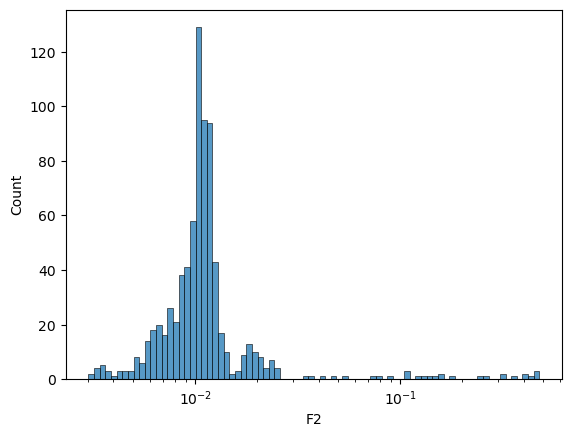

In [85]:
sns.histplot(data=df_trust_patients,
             x='F2',
             log_scale=10
            )

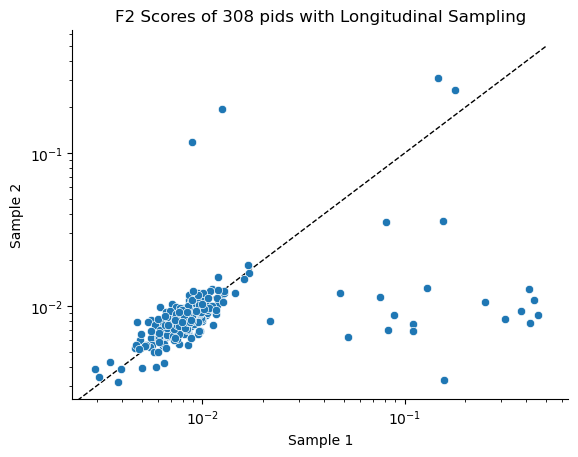

In [86]:
df_F2_longitudinal = df_longitudinal_pids.pivot(index='pid', columns='Paired_Sample_Num', values='F2').reset_index()
df_F2_longitudinal.columns = ['pid', 'Sample1', 'Sample2']
df_F2_longitudinal['F2_Diff'] = df_F2_longitudinal['Sample2'] - df_F2_longitudinal['Sample1']
df_F2_longitudinal['Abs_F2_Diff'] = np.abs(df_F2_longitudinal['F2_Diff'])

sns.scatterplot(data=df_F2_longitudinal,
                x='Sample1',
                y='Sample2',
               )

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Sample 1')
plt.ylabel('Sample 2')
plt.title(f'F2 Scores of {df_longitudinal_pids.pid.nunique()} pids with Longitudinal Sampling')

x_vals = np.linspace(0, 0.5, 10)
plt.plot(x_vals, x_vals, color='black', zorder=0, linestyle='--', linewidth=1)

sns.despine()
plt.savefig("./figures/F2_longitudinal.svg", bbox_inches='tight')

In [87]:
pids_high_F2_both = df_F2_longitudinal.query("Sample1 > 0.1 & Sample2 > 0.1").pid.unique()

df_longitudinal_pids.query("pid in @pids_high_F2_both")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,...,mix_prop,failed,mix_phylotypes,mix_props,Sampling_Interval,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop,Major_Minor_Diff
216,T0167,S0167-01,MFS-84,1,NaN,2.2.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2",NaN,...,0.8233,False,"2.2.M2.2,4.1.1.3","0.8233,0.1767",3,2.2.M2.2,0.8233,4.1.1.3,0.1767,0.6466
217,T0167,S0167-04,MFS-85,4,NaN,"2.2.1,4.1.1.3","4.1,2.2.1.1.1","beijing,xtype,mungi","lin2.2.1,asian_african_2",NaN,...,0.7423,False,"2.2.M2.2,4.1.1.3","0.7423,0.2577",3,2.2.M2.2,0.7423,4.1.1.3,0.2577,0.4846
268,T0204,S0204-01,MFS-630,1,NaN,2.2.1,2.2.1.1.1,"beijing,east_african_indian,mungi",lin2.2.1,NaN,...,0.8567,False,"2.2.M4.4,3.1.1.1","0.8567,0.1433",7,2.2.M4.4,0.8567,3.1.1.1,0.1433,0.7134
269,T0204,S0204-08,MFS-631,8,NaN,"2.2.1,3","2.2.1.1.1,3.1.1.i1","beijing,east_african_indian,mungi",lin2.2.1,NaN,...,0.6953,False,"2.2.M4.4,3.1.1.1","0.6953,0.3047",7,2.2.M4.4,0.6953,3.1.1.1,0.3047,0.3906


In [88]:
df_trust_patients.query("pid in ['T0204', 'T0167', 'T0224', 'T0235'] & Sampling_Week > 12")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
393,T0204,S0204-m5,MFS-632,MFS-632_lib66025,NaN,NaN,1.0,309.1,0.99,0.9833,...,NaN,NaN,2.0,0.238897,NaN,0.00853,2.2.1,2.2.1.1.1,2,20


In [3]:
df_tbtyper_culture = pd.read_csv("~/MtbLongitudinalDiversity/direct_sputum/culture_TBtypeR_results.csv")

# df_tbtyper_DS = pd.read_csv("~/MtbLongitudinalDiversity/direct_sputum/TBtypeR_results.csv").dropna(subset='mix_phylotype')
# df_tbtyper_DS['pid'] = df_tbtyper_DS['sample_id'].str.split('-').str[0].str.replace('S', 'T')

# df_tbtyper_DS['mix_phylotypes'] = df_tbtyper_DS.groupby('sample_id')['mix_phylotype'].transform(lambda x: ','.join(x))
# df_tbtyper_DS['mix_props'] = df_tbtyper_DS.groupby('sample_id')['mix_prop'].transform(lambda x: ','.join(np.array(x).astype(str)))

# df_tbtyper_DS = df_tbtyper_DS.drop_duplicates(subset='sample_id')

df_tbtyper_DS_culture_matched = pd.read_csv("~/MtbLongitudinalDiversity/direct_sputum/TBTypeR_full_results_matched_culture_DS.csv")

In [5]:
df_tbtyper_DS_culture_matched.pid.nunique()

133

In [7]:
df_tbtyper_DS_culture_matched.Original_ID.nunique()

141

In [10]:
df_tbtyper_DS_culture_matched['n_phy_diff'] = df_tbtyper_DS_culture_matched['n_phy'] - df_tbtyper_DS_culture_matched['cult_n_phy']

In [14]:
df_tbtyper_DS_culture_matched['n_phy_diff'].value_counts()

n_phy_diff
2.0    69
0.0    50
1.0    22
Name: count, dtype: int64

In [17]:
91/141

0.6453900709219859

In [16]:
df_tbtyper_DS_culture_matched.query("cult_n_phy > 1")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match,n_phy_diff
15,MFS-39,"2.2.M1.1,4.3.2.1","0.8965,0.1035",2,1,T0066,S0066-01,1,0.110925,2.2.1.1,2.0,1,S0066-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.4116,0.4728,0.1156",3.0,1.0,360.0,1.0,1.0
56,MFS-133,"2.2.M1.1,2.2.M4.4","0.0143,0.9857",2,1,T0224,S0224-01,1,0.012533,2.2.1,2.0,1,S0224-01,"2.2.M1.1,2.2.M4.4","0.4958,0.5042",2.0,1.0,457.0,1.0,0.0
96,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1,T0305,S0305-01,1,0.436810,"4.3.2.1,2.2.1.1",2.0,1,S0305-01,"2.2.M1.1,4.3.2.1","0.0441,0.9559",2.0,1.0,55.0,1.0,0.0
100,MFS-198,"2.2.M1.1,4.1.1.3","0.0645,0.9355",2,1,T0322,S0322-01,1,0.075920,4.1.1.3,2.0,1,S0322-01,"2.2.M1.1,4.1.1.1,4.1.1.3","0.1568,0.0264,0.8168",3.0,1.0,156.0,1.0,1.0
103,MFS-390,"2.2.M1.1,4.8.1","0.0385,0.9615",2,1,T0326,S0326-01,1,0.042705,4.8,1.0,1,S0326-01B,"2.2.M4,4.8.1,4.9","0.0425,0.9061,0.0514",3.0,1.0,19.0,1.0,1.0
119,MFS-456,"2.2.M1.1,3.5.1","0.8739,0.1261",2,1,T0367,S0367-01,1,0.130840,2.2.1.1,2.0,1,S0367-01,"2.2.M1.1,2.2.M6,3.5.1","0.5657,0.0283,0.406",3.0,1.0,195.0,1.0,1.0
123,MFS-483,"2.2.M1.1,4.1.1.3","0.4919,0.5081",2,1,T0391,S0391-01,1,0.474464,"4.1.1.3,2.2.1.1",1.0,1,S0391-01B,"2.2.M1.1,4.1.1.3,4.3.2.1","0.8776,0.1047,0.0177",3.0,1.0,372.0,1.0,1.0
124,MFS-485,"2.2.M1.1,4.1.1.3","0.926,0.074",2,1,T0393,S0393-01,1,0.079214,2.2.1.1,2.0,1,S0393-01,"2.2.M1.1,4.1.1.3","0.5174,0.4826",2.0,1.0,568.0,1.0,0.0


In [95]:
df_tbtyper_culture.query("sample_id.str.contains('MFS-632')")

,sample_id,n_phy,likelihood,error_rate,p_val_perm,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed
512,MFS-632.filtered.vcf.gz,1,-3605.029051,0.0001,0.0,-1.0,inf,1,40,2.2.M4.4,1.0,False


In [96]:
pids_increase_F2 = df_F2_longitudinal.query("Sample2 > Sample1 & Sample2 > 0.1 & Sample1 < 0.1").pid.unique()

df_longitudinal_pids.query("pid in @pids_increase_F2")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,...,mix_prop,failed,mix_phylotypes,mix_props,Sampling_Interval,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop,Major_Minor_Diff
294,T0224,S0224-01,MFS-133,1,NaN,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,...,0.9854,False,"2.2.M4.4,2.2.M1.1","0.9854,0.0146",7,2.2.M4.4,0.9854,2.2.M1.1,0.0146,0.9708
295,T0224,S0224-08,MFS-134,8,NaN,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,...,0.5815,False,"2.2.M1.1,2.2.M4.4","0.5815,0.4185",7,2.2.M1.1,0.5815,2.2.M4.4,0.4185,0.1630
306,T0235,S0235-01,MFS-144,1,NaN,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,...,1.0000,False,2.2.M1.1,1.0,4,2.2.M1.1,1.0000,NaN,NaN,NaN
307,T0235,S0235-05,MFS-145,5,NaN,4.8,4.2.1.1.1.1.1.1.i1,"beijing,canetti",NaN,4.10/PGG3,...,0.8837,False,"4.8,2.2.M1.1","0.8837,0.1163",4,4.8,0.8837,2.2.M1.1,0.1163,0.7674


In [97]:
pids_decrease_F2 = df_F2_longitudinal.query("Sample1 > Sample2 & Sample1 > @F2_max").pid.unique()

major_lineage_remaining_FU = []

for pid in pids_decrease_F2:
    
    major_lineage_1 = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').Major_Lineage.values[0]
    major_lineage_2 = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').Major_Lineage.values[-1]
    
    if major_lineage_1 == major_lineage_2:
        major_lineage_remaining_FU.append(pid)
        
len(major_lineage_remaining_FU), len(pids_decrease_F2)

(11, 18)

In [128]:
df_tbtyper_DS_culture_matched.query("pid in ['T0204', 'T0167']")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match


In [130]:
df_tbtyper_DS_culture_matched.query("pid in @pids_decrease_F2")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match
15,MFS-39,"2.2.M1.1,4.3.2.1","0.8965,0.1035",2,1,T0066,S0066-01,1,0.110925,2.2.1.1,2.0,1,S0066-01,"2.2.M1.1,2.2.M4.4,4.3.2.1","0.4116,0.4728,0.1156",3.0,1.0,360.0,1.0
96,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1,T0305,S0305-01,1,0.436810,"4.3.2.1,2.2.1.1",2.0,1,S0305-01,"2.2.M1.1,4.3.2.1","0.0441,0.9559",2.0,1.0,55.0,1.0
100,MFS-198,"2.2.M1.1,4.1.1.3","0.0645,0.9355",2,1,T0322,S0322-01,1,0.075920,4.1.1.3,2.0,1,S0322-01,"2.2.M1.1,4.1.1.1,4.1.1.3","0.1568,0.0264,0.8168",3.0,1.0,156.0,1.0
119,MFS-456,"2.2.M1.1,3.5.1","0.8739,0.1261",2,1,T0367,S0367-01,1,0.130840,2.2.1.1,2.0,1,S0367-01,"2.2.M1.1,2.2.M6,3.5.1","0.5657,0.0283,0.406",3.0,1.0,195.0,1.0
124,MFS-485,"2.2.M1.1,4.1.1.3","0.926,0.074",2,1,T0393,S0393-01,1,0.079214,2.2.1.1,2.0,1,S0393-01,"2.2.M1.1,4.1.1.3","0.5174,0.4826",2.0,1.0,568.0,1.0


In [127]:
df_tbtyper_DS_culture_matched.query("Sampling_Week > 2")

,SampleID,cult_mix_phylotypes,cult_mix_props,cult_n_phy,cult_defaultParams,pid,Original_ID,Sampling_Week,F2,Coll2014,Num_Culture_Samples,Paired_Culture_Sample,Sample,mix_phylotypes,mix_props,n_phy,defaultParams,Median_Depth,Exact_Match
48,MFS-756,2.2.M4.4,1.0,1,1,T0194,S0194-03,3,0.012164,2.2.1,1.0,1,S0194-01,"2.2.M4.4,4.1.1.3,4.3.2.1","0.4558,0.106,0.4382",3.0,0.0,12.0,1.0
69,MFS-173,2.2.M1.1,1.0,1,1,T0256,S0256-08,8,0.011113,2.2.1.1,2.0,2,S0256-08,2.2.M1.1,1.0,1.0,1.0,63.0,1.0
71,MFS-175,4.1.1.1,1.0,1,1,T0257,S0257-07,7,0.008737,4.1.1.1,2.0,2,S0257-07,4.1.1.1,1.0,1.0,1.0,298.0,1.0
78,MFS-279,2.2.M1.4,1.0,1,1,T0272,S0272-09,9,0.009560,2.2.1,2.0,2,S0272-09,2.2.M1.4,1.0,1.0,1.0,23.0,1.0
80,MFS-273,4.1.1.2,1.0,1,1,T0273,S0273-05,5,0.024653,4.1.1.2,2.0,2,S0273-05,"4.1.1.1,4.1.1.2","0.1194,0.8806",2.0,1.0,41.0,1.0
83,MFS-322,2.2.M4.4,1.0,1,1,T0276,S0276-08,8,0.013765,2.2.1,2.0,2,S0276-07,2.2.M4.4,1.0,1.0,1.0,32.0,1.0
85,MFS-297,4.3.3,1.0,1,1,T0278,S0278-06,6,0.010999,4.3.3,2.0,2,S0278-06,"2.2.M4.4,4.1.1.1,4.3.3","0.1845,0.5209,0.2946",3.0,0.0,12.0,1.0
87,MFS-299,4.3.2.1,1.0,1,1,T0279,S0279-06,6,0.012527,4.3.2.1,2.0,2,S0279-06,"2.2.M2,4.1.1.1,4.3.2.1","0.2102,0.6217,0.1681",3.0,0.0,13.0,1.0
90,MFS-326,2.2.M1.1,1.0,1,1,T0284,S0284-07,7,0.013818,2.2.1.1,2.0,2,S0284-07,2.2.M1.1,1.0,1.0,1.0,20.0,1.0
94,MFS-309,4.1.2,1.0,1,1,T0291,S0291-09,9,0.021034,4.1.2,2.0,2,S0291-09,"4.1.1.1,4.1.2","0.1459,0.8541",2.0,0.0,13.0,1.0


In [103]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid not in @major_lineage_remaining_FU")[['pid', 'SampleID', 'Sampling_Week', 'mix_phylotypes', 'mix_props', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']]

,pid,SampleID,Sampling_Week,mix_phylotypes,mix_props,F2,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop
12,T0010,MFS-336,1,"4.1.1.1,2.2.M1.1","0.5416,0.4584",0.459022,4.1.1.1,0.5416,2.2.M1.1,0.4584
13,T0010,MFS-337,8,2.2.M1.1,1.0,0.008737,2.2.M1.1,1.0000,NaN,NaN
122,T0087,MFS-353,1,"4.1.2.1,4.8","0.5709,0.4291",0.418572,4.1.2.1,0.5709,4.8,0.4291
123,T0087,MFS-354,8,4.8,1.0,0.007705,4.8,1.0000,NaN,NaN
198,T0152,MFS-608,1,"4.3.3,4.3.4.2.1","0.8456,0.1544",0.156765,4.3.3,0.8456,4.3.4.2.1,0.1544
199,T0152,MFS-609,4,4.3.4.2.1,1.0,0.003265,4.3.4.2.1,1.0000,NaN,NaN
346,T0267,MFS-270,1,"2.2.M1.1,4.3.2.1","0.7595,0.2405",0.250045,2.2.M1.1,0.7595,4.3.2.1,0.2405
347,T0267,MFS-280,6,4.3.2.1,1.0,0.010598,4.3.2.1,1.0000,NaN,NaN
476,T0367,MFS-456,1,"2.2.M1.1,3.5.1","0.8734,0.1266",0.128377,2.2.M1.1,0.8734,3.5.1,0.1266
477,T0367,MFS-457,7,3.5.1,1.0,0.013176,3.5.1,1.0000,NaN,NaN


In [125]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid not in @major_lineage_remaining_FU")[['pid', 'SampleID', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage.value_counts()

Major_Lineage
2.2.M1.1     2
4.1.1.1      1
4.1.2.1      1
4.3.3        1
2.2.M4.8     1
4.3.4.2.1    1
Name: count, dtype: int64

In [136]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid in @major_lineage_remaining_FU")[['pid', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage_Prop.mean()

0.783450373857154

In [139]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid in @major_lineage_remaining_FU")[['pid', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage.value_counts()

Major_Lineage
2.2.1.1    9
4.1.2.1    1
4.3.2.1    1
4.1.1.3    1
Name: count, dtype: int64